In [1]:
!pip install pmdarima

In [2]:
from pandas_datareader import data as pdr #read data from yahoo finance api
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

from statsmodels.tsa.stattools import adfuller # Augmented Dickey Fuller test for testing stationarity

from statsmodels.tsa.arima_model import ARIMA #for manual ARIMA
import pmdarima as pm #auto arima

In [3]:
er_visits_df = pd.read_csv('er_visits.csv')

er_visits_df

,week_end,geography,county,percent_visits_combined,percent_visits_covid,percent_visits_influenza,percent_visits_rsv,percent_visits_smoothed_combined,percent_visits_smoothed_covid,percent_visits_smoothed_influenza,percent_visits_smoothed_rsv,ed_trends_covid,ed_trends_influenza,ed_trends_rsv,hsa,hsa_counties,hsa_nci_id,fips,trend_source,BuildNumber
0,2022-10-01,Alabama,Bibb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Jefferson (Birmingham), AL - Shelby, AL","Bibb, Blount, Chilton, Cullman, Jefferson, She...",150,"1,007",HSA,2026-09-23
1,2022-10-01,Alabama,Calhoun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Calhoun (Anniston), AL - Cleburne, AL","Calhoun, Cleburne",177,"1,015",HSA,2026-09-23
2,2022-10-01,Alabama,Chilton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Jefferson (Birmingham), AL - Shelby, AL","Bibb, Blount, Chilton, Cullman, Jefferson, She...",150,"1,021",HSA,2026-09-23
3,2022-10-01,Alabama,Cleburne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Calhoun (Anniston), AL - Cleburne, AL","Calhoun, Cleburne",177,"1,029",HSA,2026-09-23
4,2022-10-01,Alabama,Coosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Talladega, AL - Clay, AL","Clay, Coosa, Talladega",241,"1,037",HSA,2026-09-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664139,2026-09-19,Wyoming,Hot Springs,NaN,0.39,0.20,0.00,NaN,0.31,0.13,0.00,No Change,No Change,No Change,"Fremont, WY - Washakie, WY","Fremont, Hot Springs, Washakie",777,"56,017",HSA,2026-09-23
664140,2026-09-19,Wyoming,Lincoln,NaN,1.01,1.62,0.61,NaN,1.61,1.45,0.28,No Change,No Change,Limited Data,"Teton, WY - Lincoln, WY","Lincoln, Sublette, Teton",775,"56,023",HSA,2026-09-23
664141,2026-09-19,Wyoming,Natrona,NaN,0.00,0.00,0.00,NaN,0.02,0.02,0.00,No Change,No Change,No Change,"Natrona (Casper), WY - Converse, WY","Converse, Natrona",726,"56,025",HSA,2026-09-23
664142,2026-09-19,Wyoming,Sweetwater,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,Limited Data,Limited Data,Limited Data,"Sweetwater, WY",Sweetwater,977,"56,037",HSA,2026-09-23


### Filtering for All Pennsylvania Counties

In [4]:
er_visits_pa = er_visits_df[(er_visits_df["county"]=="All") & 
                                   (er_visits_df["geography"]=="Pennsylvania")]
er_visits_pa.head()

,week_end,geography,county,percent_visits_combined,percent_visits_covid,percent_visits_influenza,percent_visits_rsv,percent_visits_smoothed_combined,percent_visits_smoothed_covid,percent_visits_smoothed_influenza,percent_visits_smoothed_rsv,ed_trends_covid,ed_trends_influenza,ed_trends_rsv,hsa,hsa_counties,hsa_nci_id,fips,trend_source,BuildNumber
569,2022-10-01,Pennsylvania,All,2.60,2.18,0.12,0.33,2.72,2.39,0.08,0.27,Decreasing,Increasing,Increasing,All,All,All,"42,000",State,2026-09-23
1414,2022-10-08,Pennsylvania,All,2.58,2.01,0.10,0.49,2.62,2.18,0.09,0.36,Decreasing,Increasing,Increasing,All,All,All,"42,000",State,2026-09-23
2210,2022-10-15,Pennsylvania,All,2.80,1.88,0.21,0.73,2.66,2.02,0.14,0.52,Decreasing,Increasing,Increasing,All,All,All,"42,000",State,2026-09-23
4565,2022-11-05,Pennsylvania,All,5.07,1.99,1.63,1.51,4.05,1.96,0.92,1.22,No Change,Increasing,Increasing,All,All,All,"42,000",State,2026-09-23
6198,2022-11-19,Pennsylvania,All,5.51,1.57,2.86,1.15,5.26,1.81,2.16,1.36,Decreasing,Increasing,Increasing,All,All,All,"42,000",State,2026-09-23


In [5]:
er_visits_pa["week_end"] = pd.to_datetime(er_visits_pa["week_end"])

C:\Users\tanis\AppData\Local\Temp\ipykernel_13708\1121298844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  er_visits_pa["week_end"] = pd.to_datetime(er_visits_pa["week_end"])


#### Approach 2

##### Step 1: Filter out the relevant data

In [6]:
pa_resp = er_visits_pa[[
    "week_end", "percent_visits_covid", "percent_visits_rsv", "percent_visits_influenza" 
]]
pa_resp.head()

,week_end,percent_visits_covid,percent_visits_rsv,percent_visits_influenza
569,2022-10-01,2.18,0.33,0.12
1414,2022-10-08,2.01,0.49,0.10
2210,2022-10-15,1.88,0.73,0.21
4565,2022-11-05,1.99,1.51,1.63
6198,2022-11-19,1.57,1.15,2.86


In [7]:
pa_resp = pa_resp.set_index("week_end")
pa_resp.head()

,percent_visits_covid,percent_visits_rsv,percent_visits_influenza
week_end,,,
2022-10-01,2.18,0.33,0.12
2022-10-08,2.01,0.49,0.10
2022-10-15,1.88,0.73,0.21
2022-11-05,1.99,1.51,1.63
2022-11-19,1.57,1.15,2.86


##### Step 2: Linear Interpolation for NaN Values

It would make sense to linearly interpolate normally if at most, the gap is of around 1-2 weeks. Any more than that (e.g., 3+ consecutive nan values) and we will be making a "big" assumption that the ER visits followed a linear/ straight line trend from thte preceding to the succeeding value for those 3+ weeks straight. So, first we check if there really are any 3+ weeks gap at all

No Nan values in any of the three disease-related columns found

##### Step 3: Visualize the ER visits (combined) data

In [23]:
# sort chronologically
pa_resp = pa_resp.reset_index()
pa_resp = pa_resp.sort_values("week_end")

# check duplicates BEFORE removing them
print(
    "Duplicate week_end rows:",
    pa_resp.duplicated(
        subset=["week_end"],
        keep=False
    ).sum()
)

# keep only first record for each week
pa_resp = pa_resp.drop_duplicates(
    subset=["week_end"],
    keep="first"
)

# make week_end the index
pa_resp = pa_resp.set_index("week_end")

# enforce weekly Saturday frequency
pa_resp = pa_resp.asfreq("W-SAT")

Duplicate week_end rows: 0


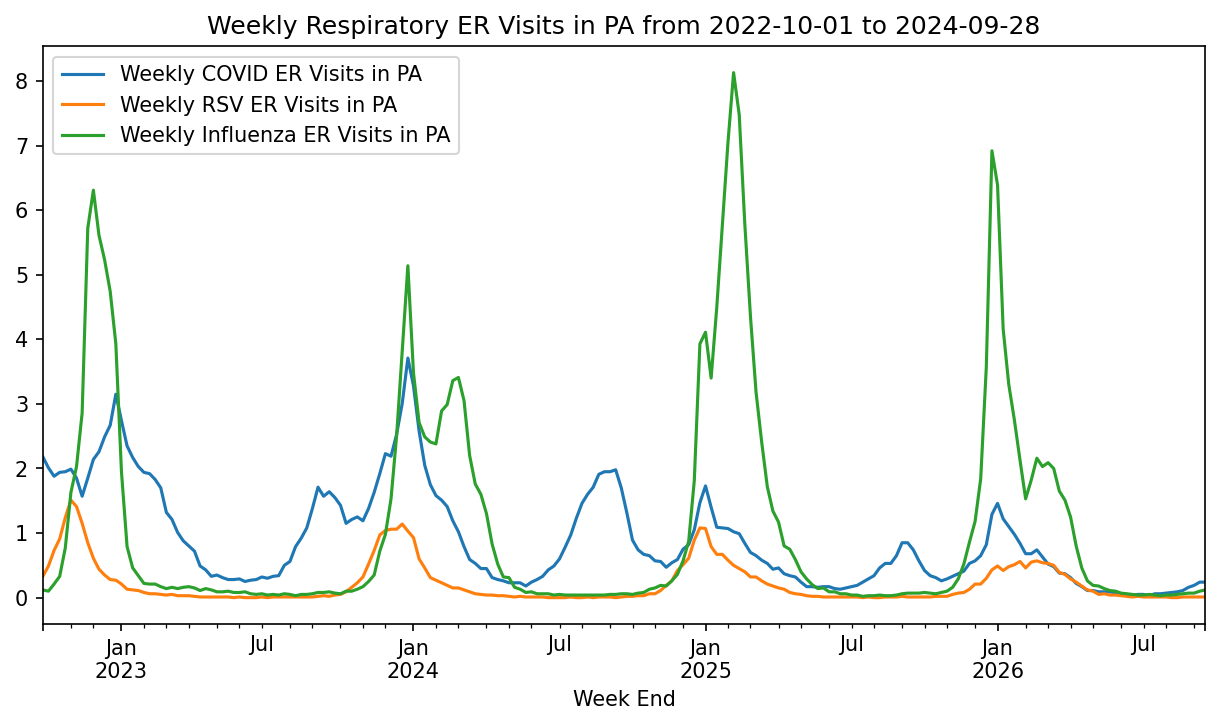

In [24]:
# Visualizing the series

# to set the plot size
plt.figure(figsize=(10, 5), dpi=150) #dpi = resolution. default 100.

# in plot method we set the label and color of the curve.
pa_resp['percent_visits_covid'].plot(label='Weekly COVID ER Visits in PA')
pa_resp['percent_visits_rsv'].plot(label='Weekly RSV ER Visits in PA')
pa_resp['percent_visits_influenza'].plot(label='Weekly Influenza ER Visits in PA')

# adding title to the plot
plt.title('Weekly Respiratory ER Visits in PA from {} to {}'.format('2022-10-01', '2024-09-28'))

# adding Label to the x-axis
plt.xlabel('Week End')

# adding legend to the curve
plt.legend()


We observe strong seasonality, so I doubt this series is stationary. Next step is to confirm this with the ACF plot and the ADF test

##### Step 4: Stationarizing the Data

In [26]:
covid_df = pa_resp[["percent_visits_covid"]]
influenza_df = pa_resp[["percent_visits_influenza"]]
rsv_df = pa_resp[["percent_visits_rsv"]]

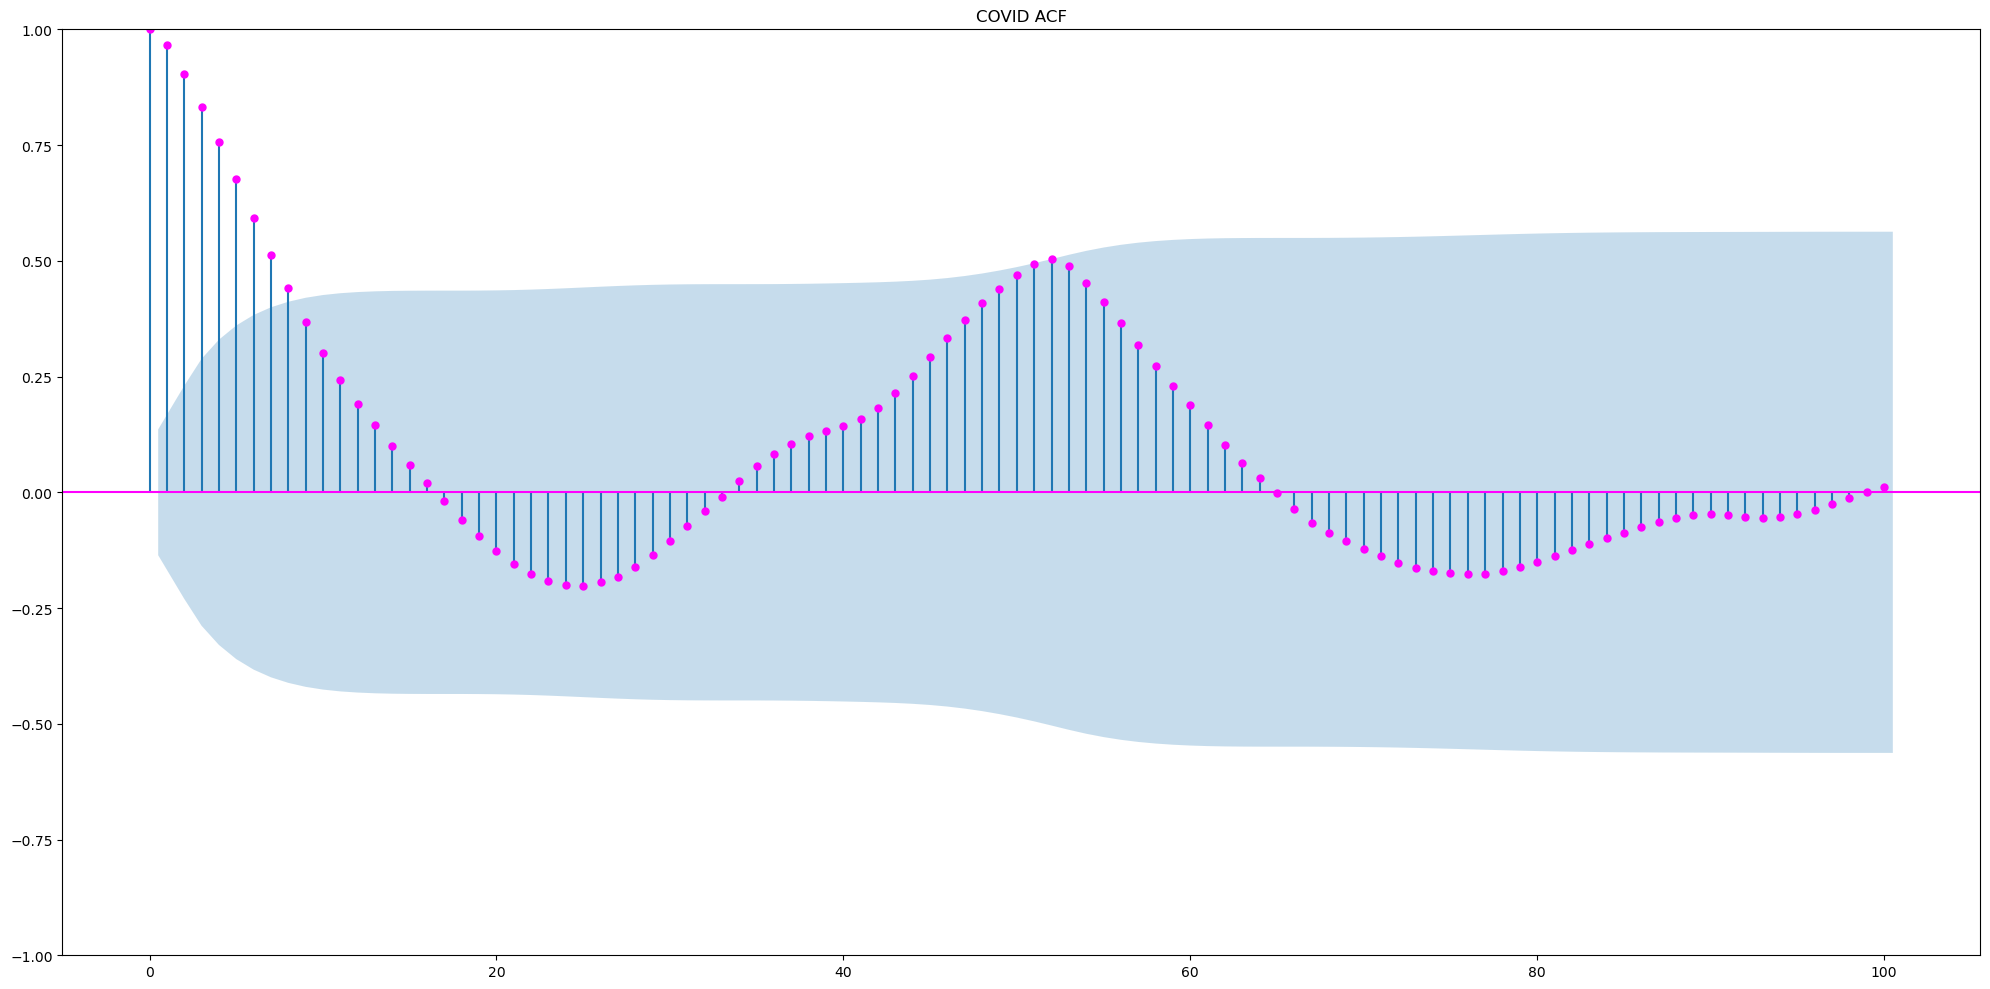

In [60]:
#check if the data is stationary

# autocorrelation plot of the dataset
fig = plot_acf(covid_df, lags=100, color="magenta")
fig.set_size_inches((20, 10))
# Tight layout to realign things
fig.tight_layout()
plt.title("COVID ACF")
plt.show()

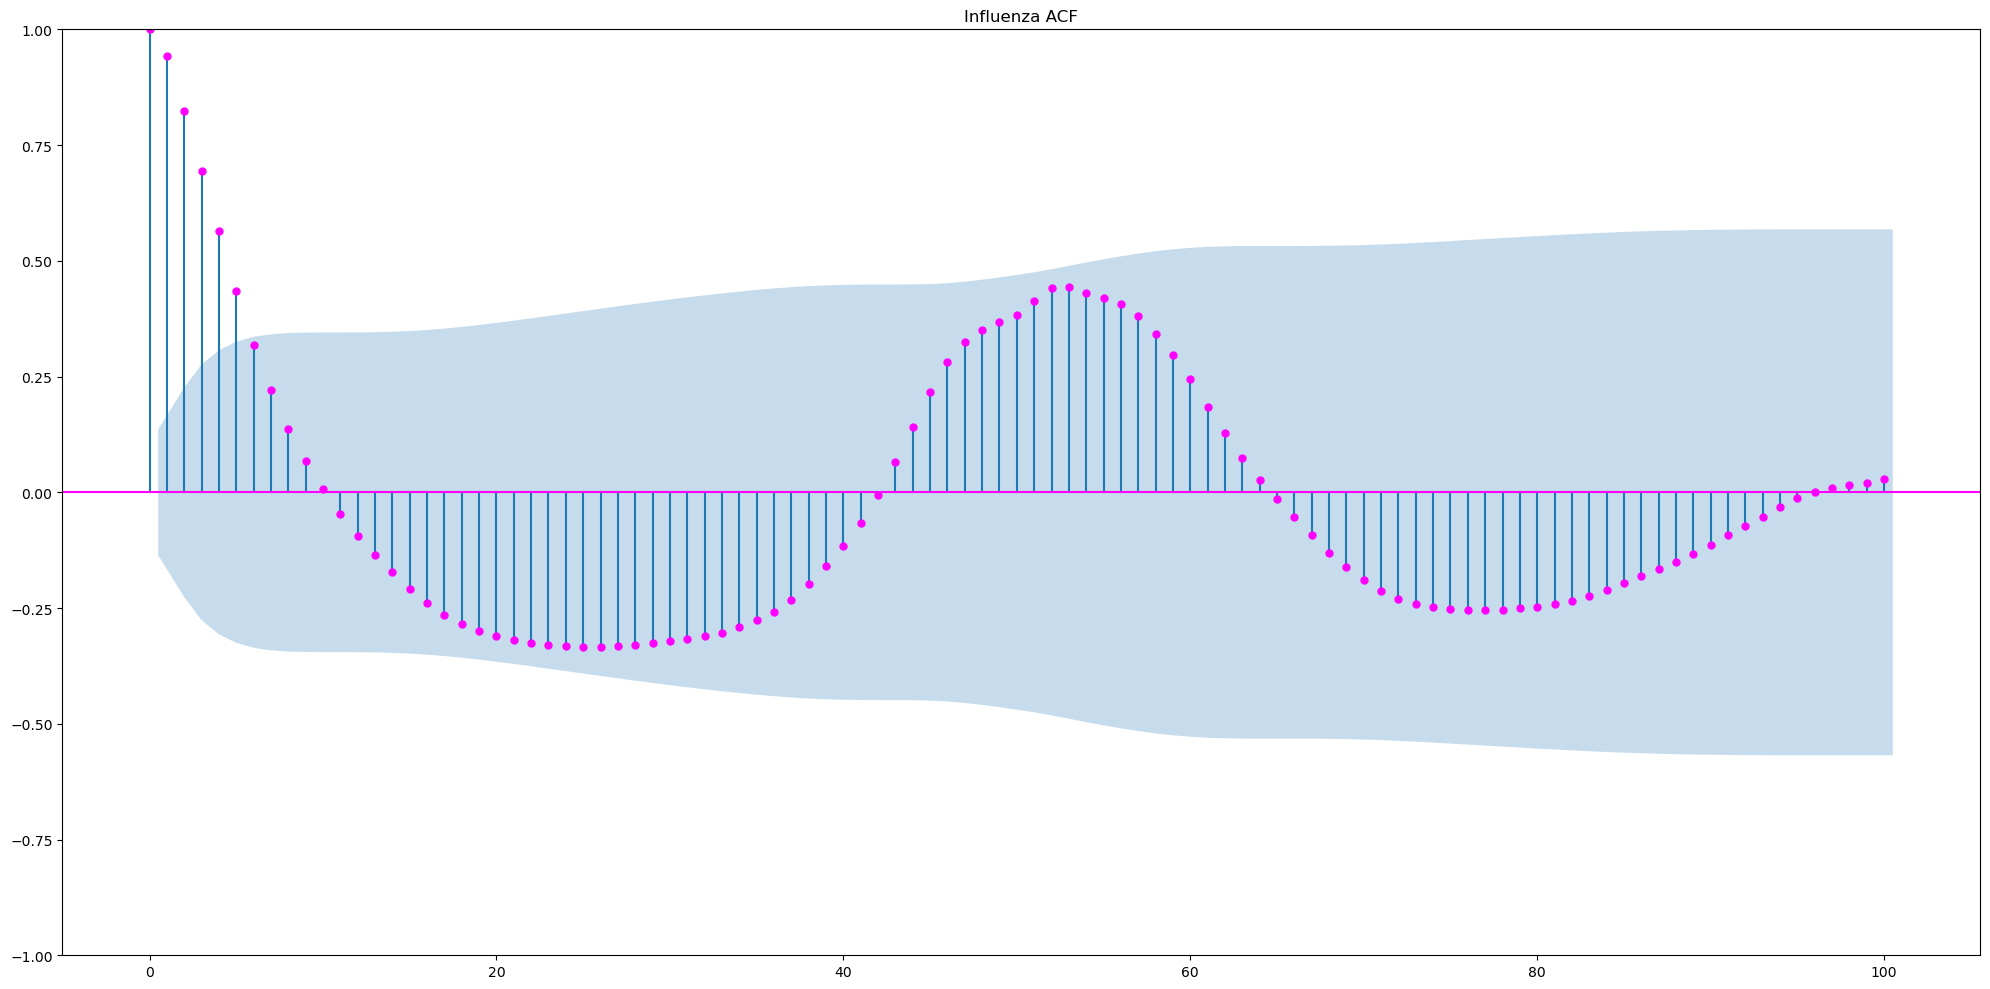

In [61]:
#check if the data is stationary

# autocorrelation plot of the dataset
fig = plot_acf(influenza_df, lags=100, color="magenta")
fig.set_size_inches((20, 10))
# Tight layout to realign things
fig.tight_layout()
plt.title("Influenza ACF")
plt.show()

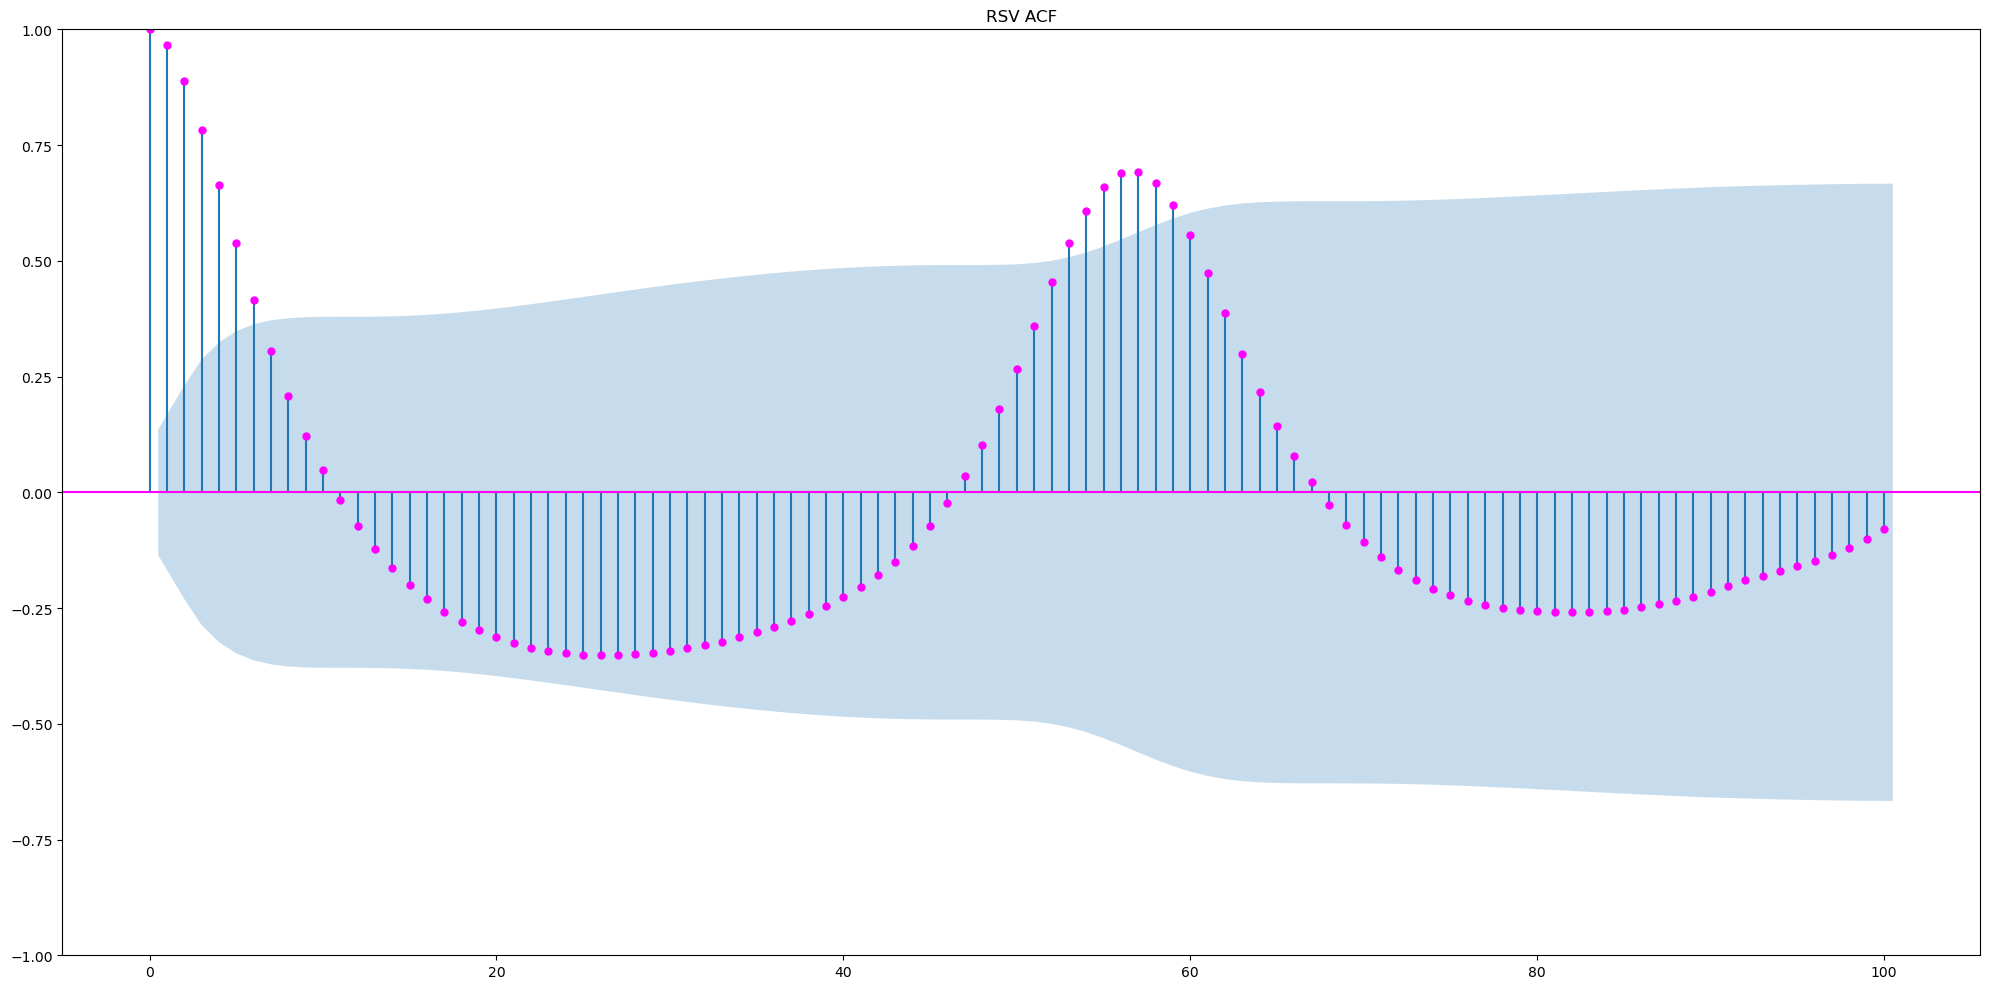

In [62]:
#check if the data is stationary

# autocorrelation plot of the dataset
fig = plot_acf(rsv_df, lags=100, color="magenta")
fig.set_size_inches((20, 10))
# Tight layout to realign things
fig.tight_layout()
plt.title("RSV ACF")
plt.show()

Very clear seasonality according to the ACF plot

In [30]:
X = covid_df.values

## adf test
result = adfuller(X)

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.362004
p-value: 0.012324
Critical Values:
	1%: -3.463
	5%: -2.876
	10%: -2.574


C:\Users\tanis\AppData\Local\Temp\ipykernel_13708\1817107663.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


In [31]:
X = influenza_df.values

## adf test
result = adfuller(X)

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.463950
p-value: 0.000228
Critical Values:
	1%: -3.463
	5%: -2.876
	10%: -2.574


C:\Users\tanis\AppData\Local\Temp\ipykernel_13708\1268272518.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


In [32]:
X = rsv_df.values

## adf test
result = adfuller(X)

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -5.298738
p-value: 0.000006
Critical Values:
	1%: -3.463
	5%: -2.876
	10%: -2.574


C:\Users\tanis\AppData\Local\Temp\ipykernel_13708\1500453986.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


##### Step 5: Splitting Data into Train and Test Sets

In [40]:
from sklearn.model_selection import train_test_split

train_data_1, test_data_1 = train_test_split(covid_df, test_size=12, random_state=25, shuffle = False)
#shuffle = False is very important to ensure the order of the data

print(f"No. of training examples in Set 1: {train_data_1.shape[0]}")
print(f"No. of testing examples in Set 1: {test_data_1.shape[0]}")

No. of training examples in Set 1: 196
No. of testing examples in Set 1: 12


In [41]:
from sklearn.model_selection import train_test_split

train_data_2, test_data_2 = train_test_split(influenza_df, test_size=12, random_state=25, shuffle = False)
#shuffle = False is very important to ensure the order of the data

print(f"No. of training examples in Set 1: {train_data_2.shape[0]}")
print(f"No. of testing examples in Set 1: {test_data_2.shape[0]}")

No. of training examples in Set 1: 196
No. of testing examples in Set 1: 12


In [42]:
from sklearn.model_selection import train_test_split

train_data_3, test_data_3 = train_test_split(rsv_df, test_size=12, random_state=25, shuffle = False)
#shuffle = False is very important to ensure the order of the data

print(f"No. of training examples in Set 1: {train_data_3.shape[0]}")
print(f"No. of testing examples in Set 1: {test_data_3.shape[0]}")

No. of training examples in Set 1: 196
No. of testing examples in Set 1: 12


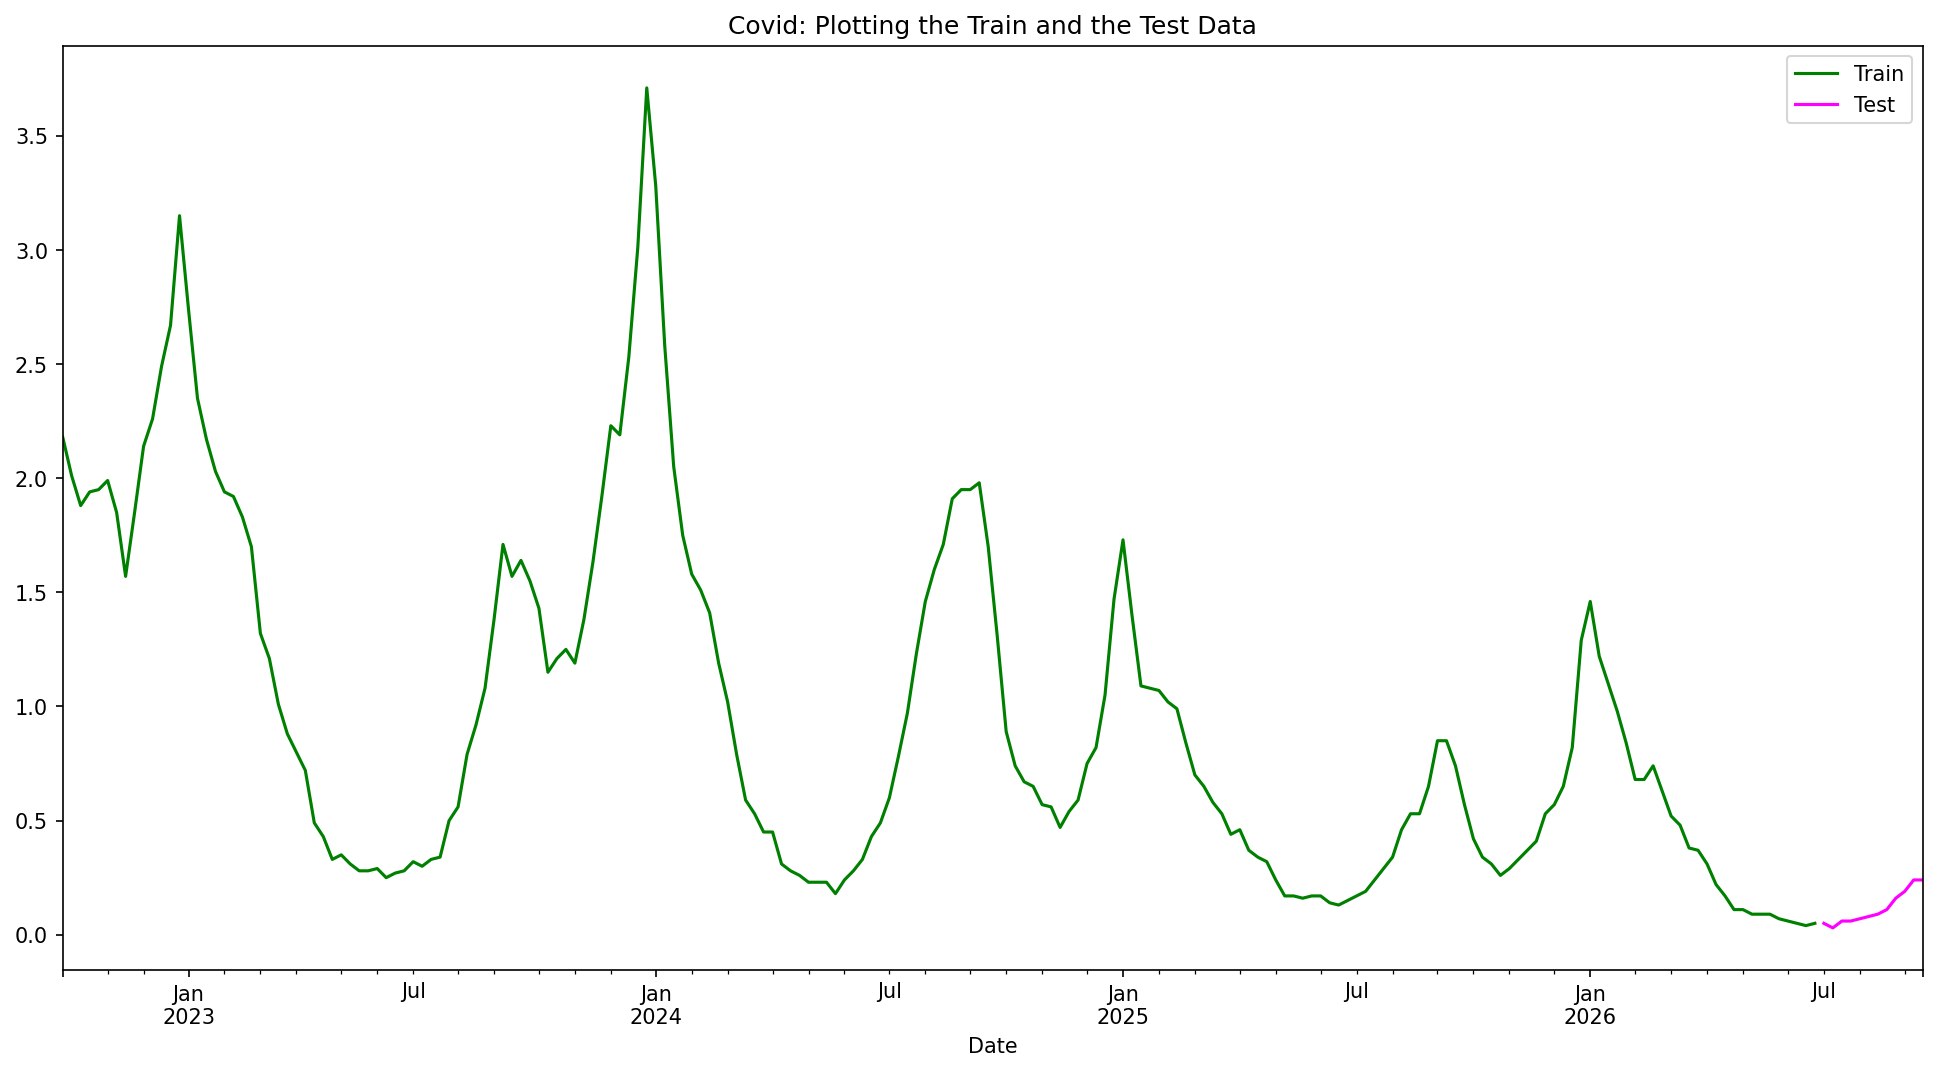

In [43]:
#Plot train and test data

# to set the plot size
plt.figure(figsize=(16, 8), dpi=150)

# using plot method to plot close prices.
# in plot method we set the label and color of the curve.
train_data_1['percent_visits_covid'].plot(label='Train', color="green")
test_data_1['percent_visits_covid'].plot(label='Test', color="magenta")

# adding Label to the x-axis
plt.xlabel('Date')
plt.title("Covid: Plotting the Train and the Test Data")
# adding legend to the curve
plt.legend()

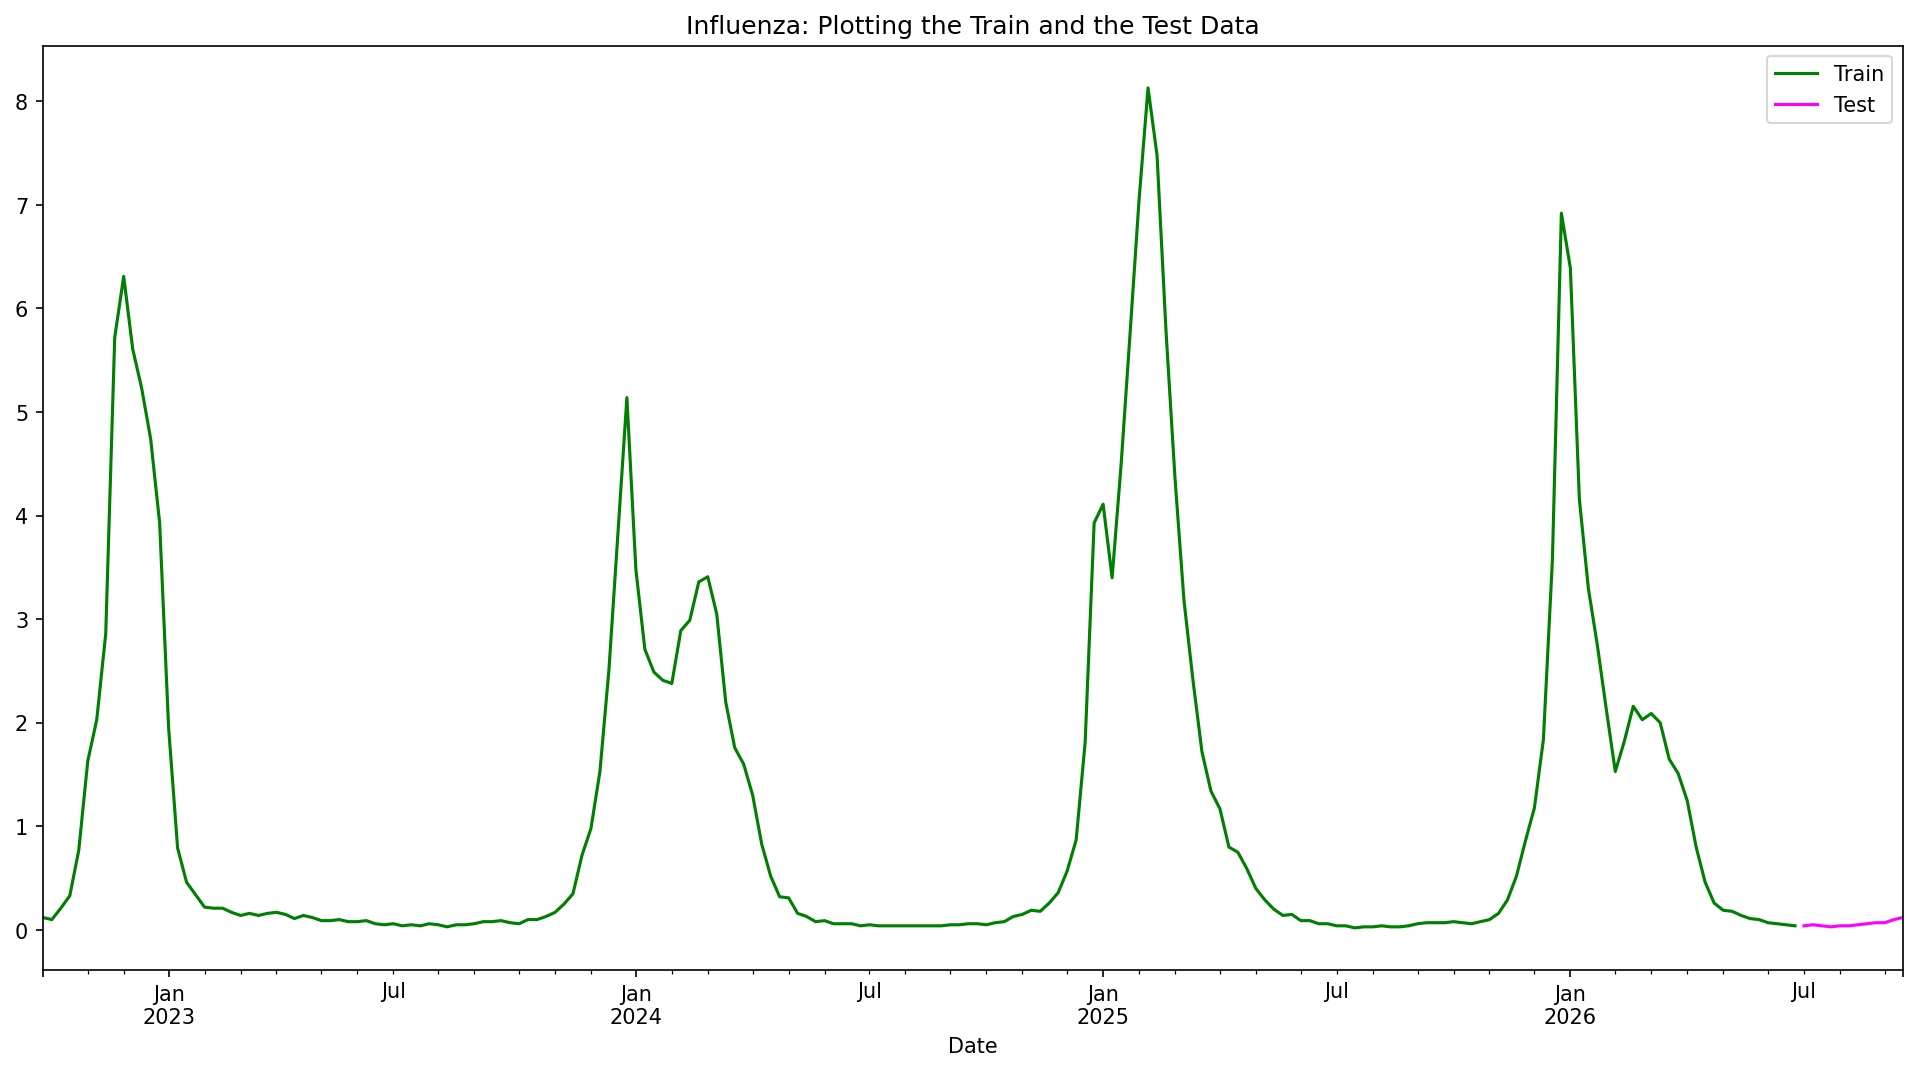

In [44]:
#Plot train and test data

# to set the plot size
plt.figure(figsize=(16, 8), dpi=150)

# using plot method to plot close prices.
# in plot method we set the label and color of the curve.
train_data_2['percent_visits_influenza'].plot(label='Train', color="green")
test_data_2['percent_visits_influenza'].plot(label='Test', color="magenta")

# adding Label to the x-axis
plt.xlabel('Date')
plt.title("Influenza: Plotting the Train and the Test Data")
# adding legend to the curve
plt.legend()

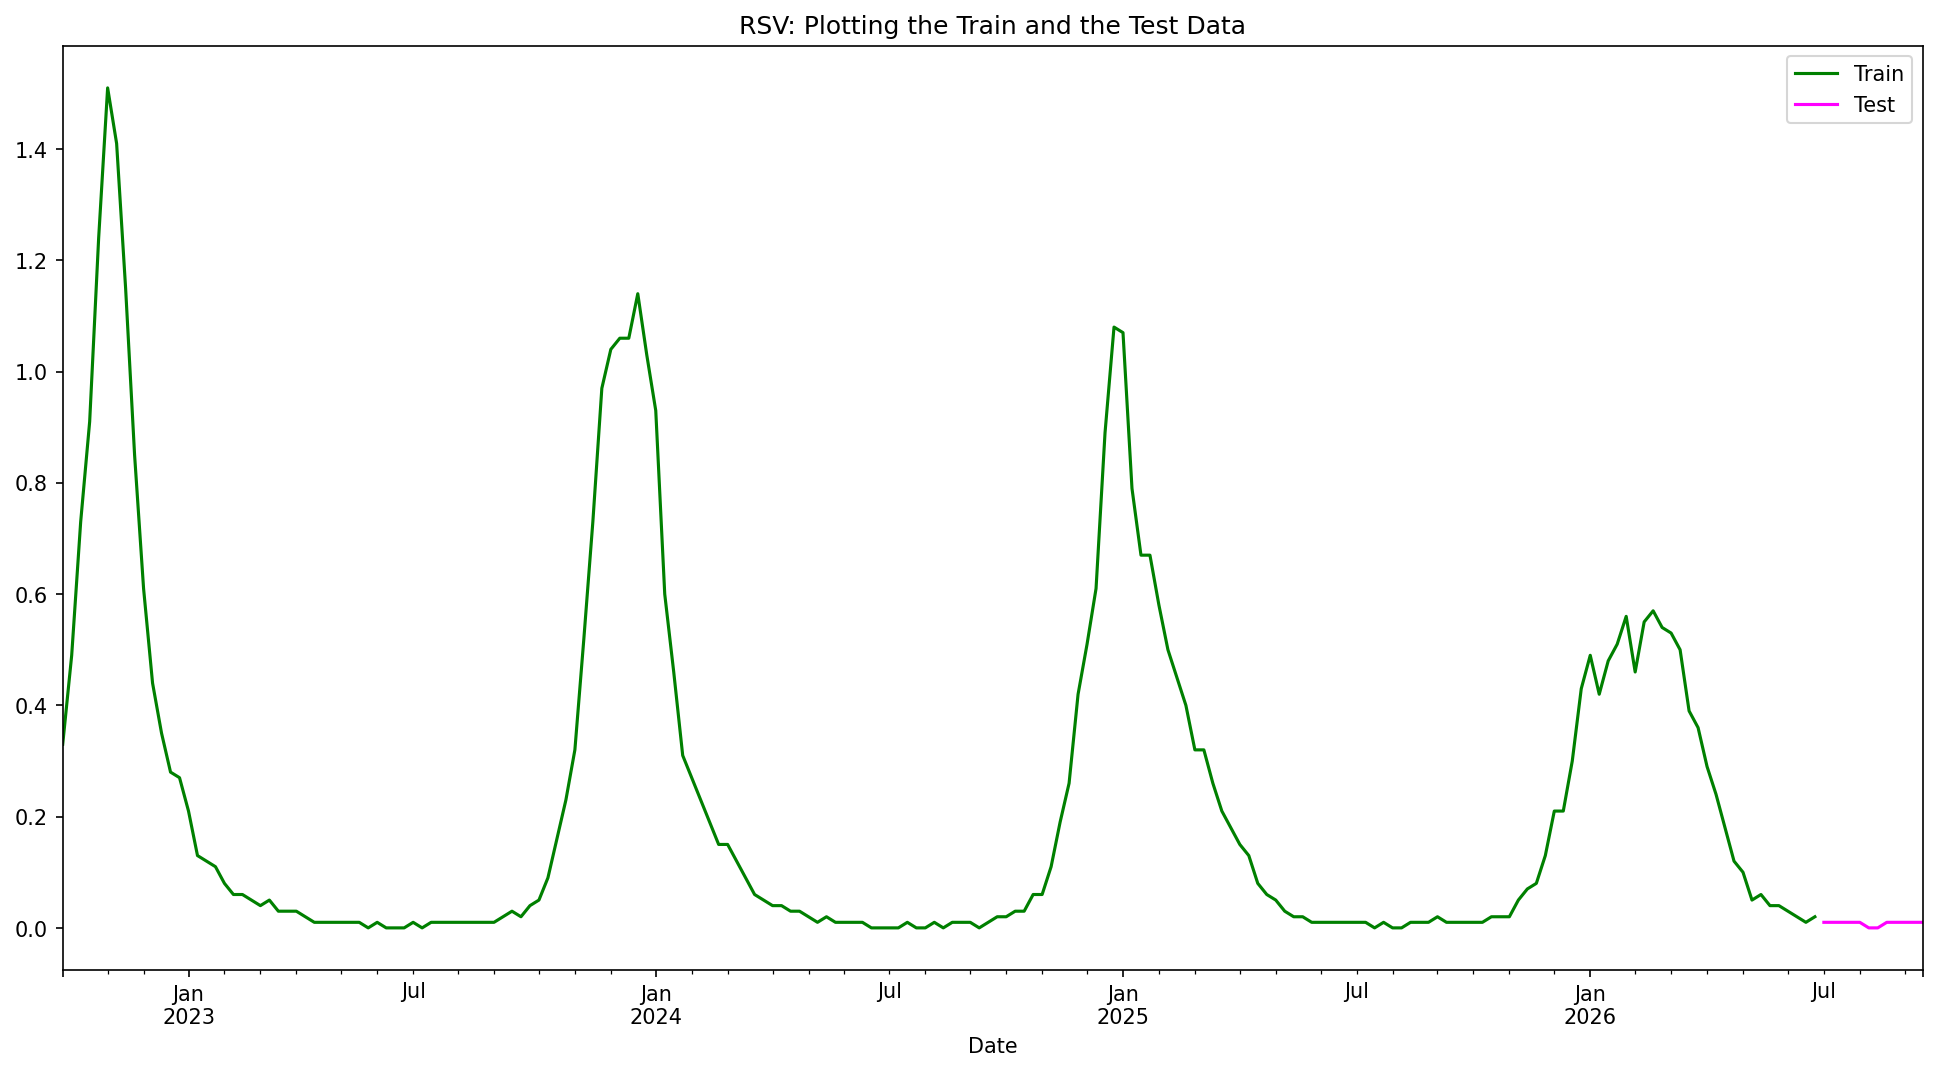

In [45]:
#Plot train and test data

# to set the plot size
plt.figure(figsize=(16, 8), dpi=150)

# using plot method to plot close prices.
# in plot method we set the label and color of the curve.
train_data_3['percent_visits_rsv'].plot(label='Train', color="green")
test_data_3['percent_visits_rsv'].plot(label='Test', color="magenta")

# adding Label to the x-axis
plt.xlabel('Date')
plt.title("RSV: Plotting the Train and the Test Data")
# adding legend to the curve
plt.legend()

##### Step 6: Fitting Multiple ETS and ARIMA Models

Since the ACF plot gradually tails off in a wave like pattern instead of cutting off sharply, we can choose q = 0

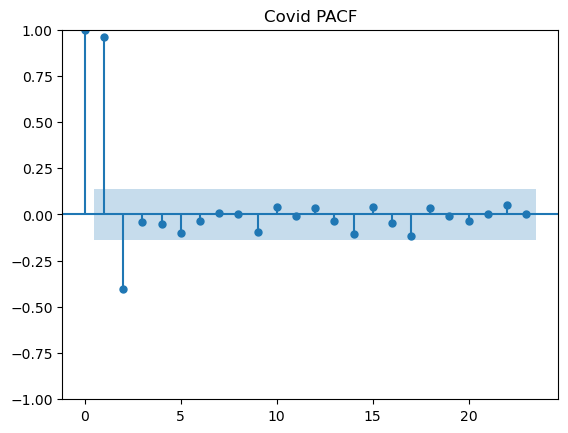

In [49]:
#plot PACF of the differenced time series.
plot_pacf(train_data_1)
plt.title("Covid PACF")
plt.show()

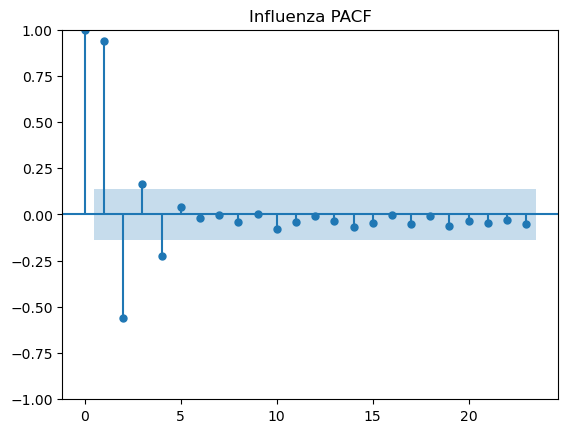

In [50]:
#plot PACF of the differenced time series.
plot_pacf(train_data_2)
plt.title("Influenza PACF")
plt.show()

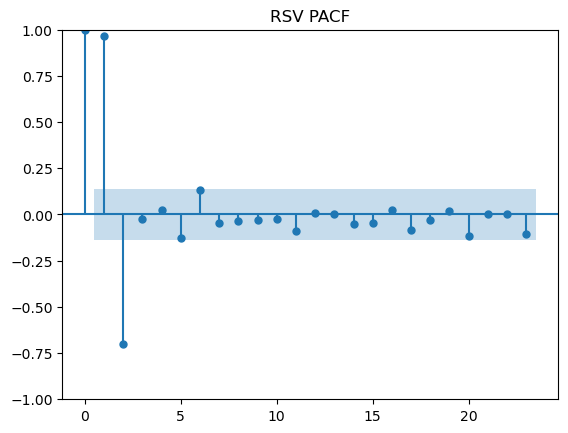

In [51]:
#plot PACF of the differenced time series.
plot_pacf(train_data_3)
plt.title("RSV PACF")
plt.show()

In [52]:
# Manual ARIMA
# p,d,q = 2,0,0 ARIMA Model
manual_model_1 = sm.tsa.ARIMA(train_data_1, order=(2,0,0))
manual_model_fit_1 = manual_model_1.fit()
print(manual_model_fit_1.summary())

                                SARIMAX Results                                 
Dep. Variable:     percent_visits_covid   No. Observations:                  196
Model:                   ARIMA(2, 0, 0)   Log Likelihood                  96.892
Date:                  Mon, 28 Sep 2026   AIC                           -185.783
Time:                          00:02:49   BIC                           -172.671
Sample:                      10-01-2022   HQIC                          -180.475
                           - 06-27-2026                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9712      0.331      2.937      0.003       0.323       1.619
ar.L1          1.5300      0.039     39.736      0.000       1.455       1.605
ar.L2         -0.5714      0.044    

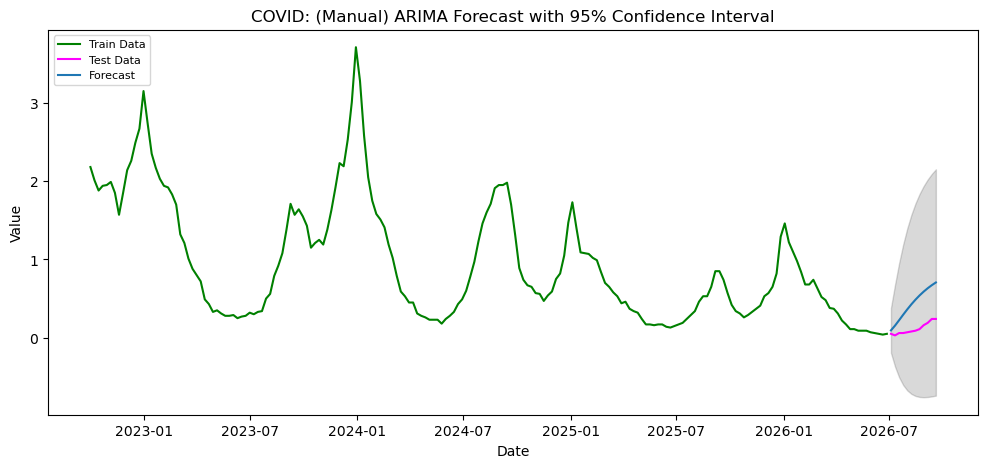

In [53]:
# Forecast
forecast_steps = 12
forecast_values = manual_model_fit_1.forecast(steps=forecast_steps)

# Calculate the standard errors of the forecasts
stderr = manual_model_fit_1.get_prediction(start=len(train_data_1), end=len(train_data_1) + forecast_steps - 1).se_mean

# Calculate lower and upper bounds for a 95% confidence interval
alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series_set1 = pd.Series(forecast_values, index=test_data_1.index)
lower_series = pd.Series(lower_bound, index=test_data_1.index)
upper_series = pd.Series(upper_bound, index=test_data_1.index)

# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data_1, label='Train Data', color="green")
plt.plot(test_data_1, label='Test Data', color="magenta")
plt.plot(fc_series_set1, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('COVID: (Manual) ARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

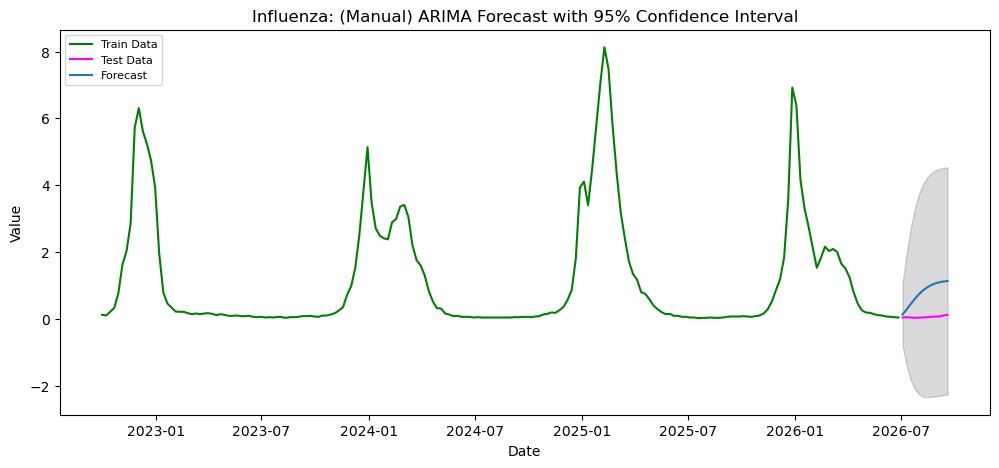

In [54]:
# Manual ARIMA
# p,d,q = 2,0,0 ARIMA Model
manual_model_2 = sm.tsa.ARIMA(train_data_2, order=(2,0,0))
manual_model_fit_2 = manual_model_2.fit()
# Forecast
forecast_steps = 12
forecast_values = manual_model_fit_2.forecast(steps=forecast_steps)

# Calculate the standard errors of the forecasts
stderr = manual_model_fit_2.get_prediction(start=len(train_data_2), end=len(train_data_2) + forecast_steps - 1).se_mean

# Calculate lower and upper bounds for a 95% confidence interval
alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series_set2 = pd.Series(forecast_values, index=test_data_2.index)
lower_series = pd.Series(lower_bound, index=test_data_2.index)
upper_series = pd.Series(upper_bound, index=test_data_2.index)

# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data_2, label='Train Data', color="green")
plt.plot(test_data_2, label='Test Data', color="magenta")
plt.plot(fc_series_set2, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('Influenza: (Manual) ARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

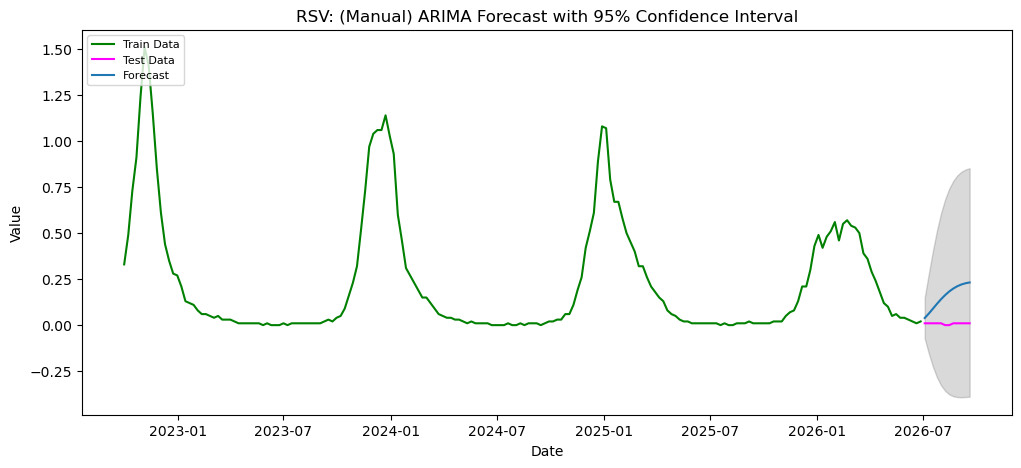

In [55]:
# Manual ARIMA
# p,d,q = 2,0,0 ARIMA Model
manual_model_3 = sm.tsa.ARIMA(train_data_3, order=(2,0,0))
manual_model_fit_3 = manual_model_3.fit()
# Forecast
forecast_steps = 12
forecast_values = manual_model_fit_3.forecast(steps=forecast_steps)

# Calculate the standard errors of the forecasts
stderr = manual_model_fit_3.get_prediction(start=len(train_data_3), end=len(train_data_3) + forecast_steps - 1).se_mean

# Calculate lower and upper bounds for a 95% confidence interval
alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series_set3 = pd.Series(forecast_values, index=test_data_3.index)
lower_series = pd.Series(lower_bound, index=test_data_3.index)
upper_series = pd.Series(upper_bound, index=test_data_3.index)

# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data_3, label='Train Data', color="green")
plt.plot(test_data_3, label='Test Data', color="magenta")
plt.plot(fc_series_set3, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('RSV: (Manual) ARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

c:\Users\tanis\anaconda3\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (52) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=632.989, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=394.888, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-169.789, Time=0.17 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-181.461, Time=0.21 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-181.273, Time=0.09 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-179.620, Time=0.22 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-181.953, Time=0.18 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-183.817, Time=0.10 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=201.219, Time=0.08 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-181.925, Time=0.20 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.60 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-180.092, Time=0.33 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-186.494, Time=0.17 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=59.1

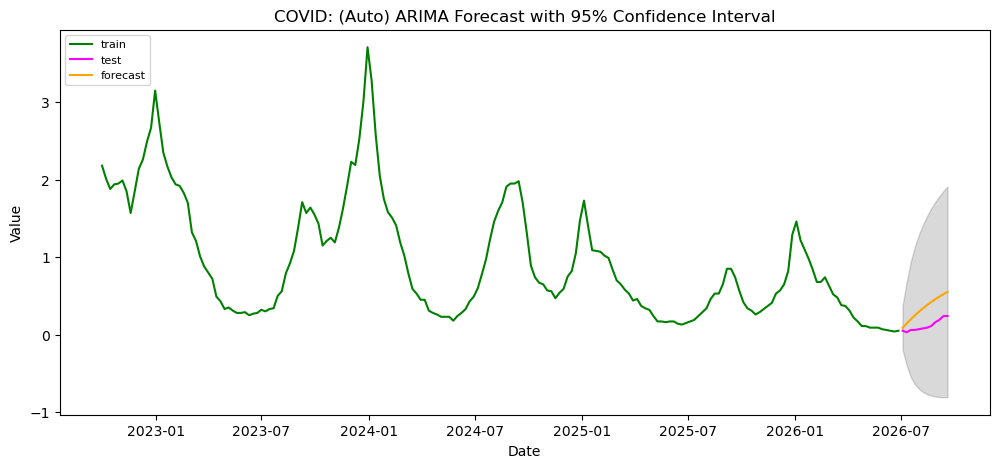

In [56]:
non_seasonal_auto_model_1 = pm.auto_arima(train_data_1, start_p=0, start_q=0,
                          test='adf',       # use adftest to find optimal 'd', like we did earlier in the notebook
                          max_p=3, max_q=3, # maximum p and q
                          m=52,              # frequency of series
                          d=None,           # let model determine 'd'
                          seasonal=False,   # No Seasonality
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)
# Forecast
n_periods = 12
fc_auto_nonseasonal_1, confint_1 = non_seasonal_auto_model_1.predict(n_periods=n_periods, return_conf_int=True)
# make series for plotting purpose
fc_series_auto_nonseasonal_1 = pd.Series(fc_auto_nonseasonal_1, index=test_data_1.index)
lower_series = pd.Series(confint_1[:, 0], index=test_data_1.index)
upper_series = pd.Series(confint_1[:, 1], index=test_data_1.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data_1, label='train', color="green")
plt.plot(test_data_1, label='test', color="magenta")
plt.plot(fc_series_auto_nonseasonal_1, color='orange', label='forecast')
plt.title('COVID: (Auto) ARIMA Forecast with 95% Confidence Interval')
plt.fill_between(lower_series.index,
                 lower_series,
                 upper_series,
                 color='k', alpha=.15)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

c:\Users\tanis\anaconda3\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (52) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=850.318, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=357.674, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=612.026, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=286.303, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=278.834, Time=0.10 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=270.794, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=269.170, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=271.478, Time=0.05 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=270.051, Time=0.17 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=269.710, Time=0.14 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=272.030, Time=0.21 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=266.858, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=270.403, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=281.830, Time=0.10 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=268.0

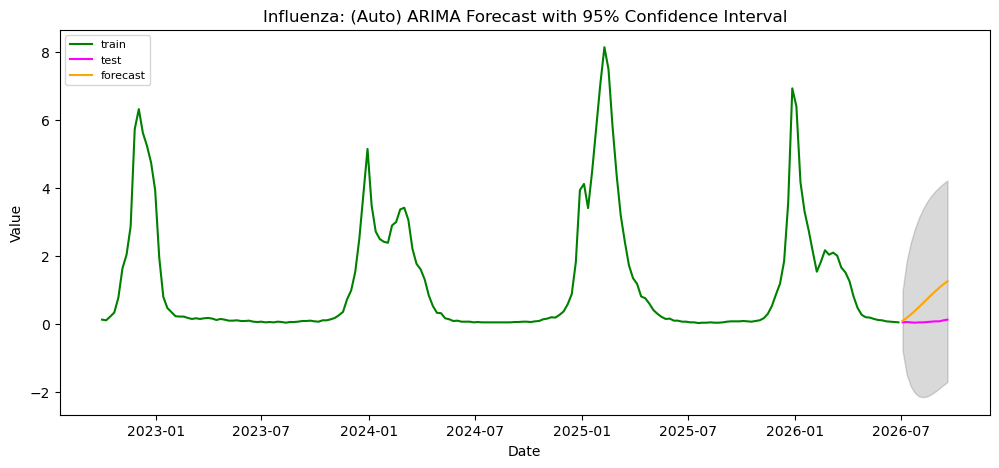

In [57]:
non_seasonal_auto_model_2 = pm.auto_arima(train_data_2, start_p=0, start_q=0,
                          test='adf',       # use adftest to find optimal 'd', like we did earlier in the notebook
                          max_p=3, max_q=3, # maximum p and q
                          m=52,              # frequency of series
                          d=None,           # let model determine 'd'
                          seasonal=False,   # No Seasonality
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)
# Forecast
n_periods = 12
fc_auto_nonseasonal_2, confint_2 = non_seasonal_auto_model_2.predict(n_periods=n_periods, return_conf_int=True)
# make series for plotting purpose
fc_series_auto_nonseasonal_2 = pd.Series(fc_auto_nonseasonal_2, index=test_data_2.index)
lower_series = pd.Series(confint_2[:, 0], index=test_data_2.index)
upper_series = pd.Series(confint_2[:, 1], index=test_data_2.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data_2, label='train', color="green")
plt.plot(test_data_2, label='test', color="magenta")
plt.plot(fc_series_auto_nonseasonal_2, color='orange', label='forecast')
plt.title('Influenza: (Auto) ARIMA Forecast with 95% Confidence Interval')
plt.fill_between(lower_series.index,
                 lower_series,
                 upper_series,
                 color='k', alpha=.15)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

c:\Users\tanis\anaconda3\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (52) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=194.212, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-415.329, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-41.066, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-551.181, Time=0.10 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-549.252, Time=0.22 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-549.244, Time=0.22 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-499.230, Time=0.16 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-550.383, Time=0.35 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-555.880, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-414.917, Time=0.15 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-553.910, Time=0.31 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-553.903, Time=0.22 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-499.309, Time=0.28 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-555.445, Time=0.58 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0

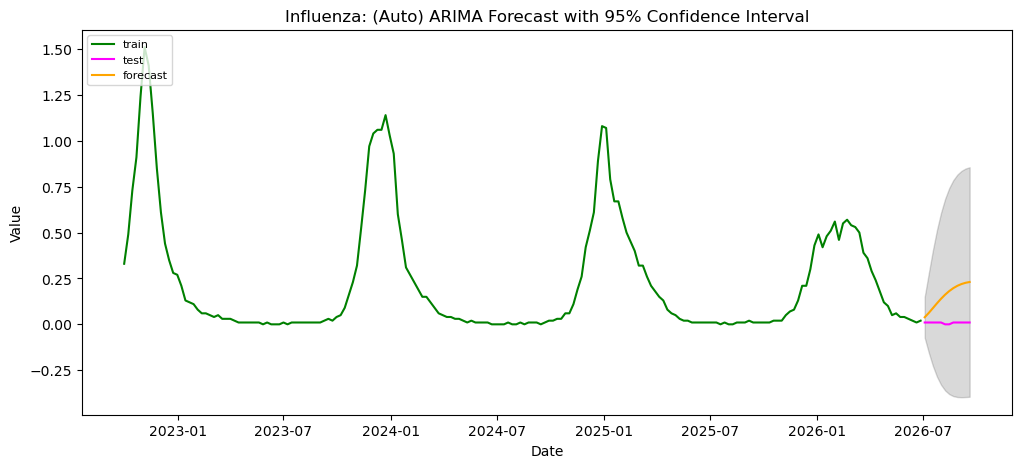

In [58]:
non_seasonal_auto_model_3 = pm.auto_arima(train_data_3, start_p=0, start_q=0,
                          test='adf',       # use adftest to find optimal 'd', like we did earlier in the notebook
                          max_p=3, max_q=3, # maximum p and q
                          m=52,              # frequency of series
                          d=None,           # let model determine 'd'
                          seasonal=False,   # No Seasonality
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)
# Forecast
n_periods = 12
fc_auto_nonseasonal_3, confint_3 = non_seasonal_auto_model_3.predict(n_periods=n_periods, return_conf_int=True)
# make series for plotting purpose
fc_series_auto_nonseasonal_3 = pd.Series(fc_auto_nonseasonal_3, index=test_data_3.index)
lower_series = pd.Series(confint_3[:, 0], index=test_data_3.index)
upper_series = pd.Series(confint_3[:, 1], index=test_data_3.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data_3, label='train', color="green")
plt.plot(test_data_3, label='test', color="magenta")
plt.plot(fc_series_auto_nonseasonal_3, color='orange', label='forecast')
plt.title('Influenza: (Auto) ARIMA Forecast with 95% Confidence Interval')
plt.fill_between(lower_series.index,
                 lower_series,
                 upper_series,
                 color='k', alpha=.15)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

c:\Users\tanis\anaconda3\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (52) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=194.212, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-415.329, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-41.066, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-551.181, Time=0.11 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-549.252, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-549.244, Time=0.16 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-499.230, Time=0.13 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-550.383, Time=0.25 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-555.880, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-414.917, Time=0.24 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-553.910, Time=0.34 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-553.903, Time=0.22 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-499.309, Time=0.19 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-555.445, Time=0.41 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0

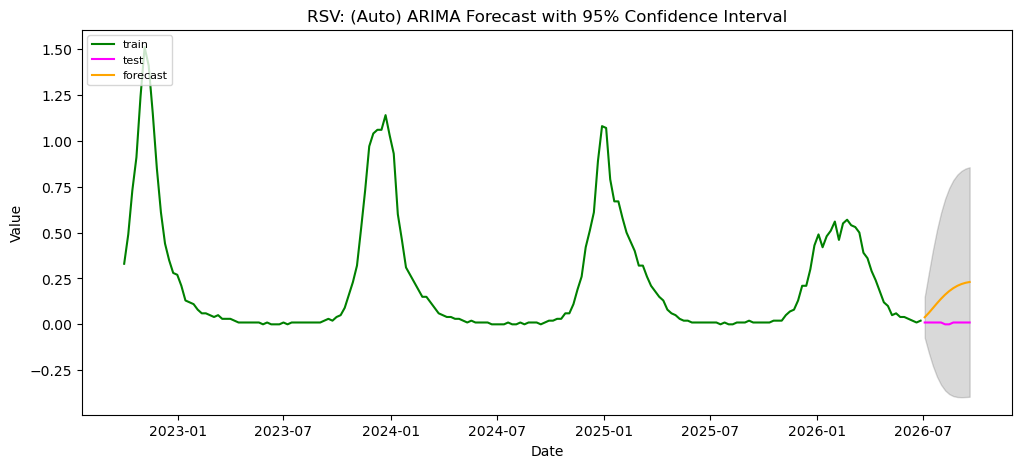

In [59]:
non_seasonal_auto_model_3 = pm.auto_arima(train_data_3, start_p=0, start_q=0,
                          test='adf',       # use adftest to find optimal 'd', like we did earlier in the notebook
                          max_p=3, max_q=3, # maximum p and q
                          m=52,              # frequency of series
                          d=None,           # let model determine 'd'
                          seasonal=False,   # No Seasonality
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)
# Forecast
n_periods = 12
fc_auto_nonseasonal_3, confint_3 = non_seasonal_auto_model_3.predict(n_periods=n_periods, return_conf_int=True)
# make series for plotting purpose
fc_series_auto_nonseasonal_3 = pd.Series(fc_auto_nonseasonal_3, index=test_data_3.index)
lower_series = pd.Series(confint_3[:, 0], index=test_data_3.index)
upper_series = pd.Series(confint_3[:, 1], index=test_data_3.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data_3, label='train', color="green")
plt.plot(test_data_3, label='test', color="magenta")
plt.plot(fc_series_auto_nonseasonal_3, color='orange', label='forecast')
plt.title('RSV: (Auto) ARIMA Forecast with 95% Confidence Interval')
plt.fill_between(lower_series.index,
                 lower_series,
                 upper_series,
                 color='k', alpha=.15)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [67]:
# # Forecast
# # Seasonal - fit stepwise auto-ARIMA
# # Seasonal - fit stepwise auto-ARIMA
# smodel_1 = pm.auto_arima(
#     train_data_1,
#     start_p=1,
#     start_q=0,
#     test='adf',
#     max_p=3,
#     max_q=3,
#     m=52,

#     start_P=0,
#     start_Q=0,
#     max_P=1,
#     max_Q=1,

#     seasonal=True,
#     d=None,
#     D=1,
#     trace=True,
#     error_action='ignore',
#     suppress_warnings=True,
#     stepwise=True
# )

# # Forecast
# fc_auto_seasonal_1, confint_1 = smodel_1.predict(n_periods=n_periods, return_conf_int=True)

# # make series for plotting purpose
# fc_series_auto_seasonal_1 = pd.Series(fc_auto_seasonal_1, index=test_data_1.index)
# lower_series = pd.Series(confint_1[:, 0], index=test_data_1.index)
# upper_series = pd.Series(confint_1[:, 1], index=test_data_1.index)

# # Plot
# plt.figure(figsize=(12,5), dpi=100)
# plt.plot(train_data_1, label='train data', color="green")
# plt.plot(test_data_1, label='test data', color="magenta")
# plt.plot(fc_series_auto_seasonal_1, label='forecast', color="orange")
# plt.fill_between(lower_series.index, lower_series, upper_series,
#                  color='k', alpha=.15)
# plt.title('COVID: (Auto) SARIMA Forecast with 95% Confidence Interval')
# plt.legend(loc='upper left', fontsize=8)
# plt.show()

                                     SARIMAX Results                                      
Dep. Variable:               percent_visits_covid   No. Observations:                  196
Model:             SARIMAX(2, 0, 0)x(0, 1, 0, 52)   Log Likelihood                  71.564
Date:                            Mon, 28 Sep 2026   AIC                           -137.129
Time:                                    00:58:40   BIC                           -128.219
Sample:                                10-01-2022   HQIC                          -133.508
                                     - 06-27-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3338      0.062     21.369      0.000       1.212       1.456
ar.L2         -0.3827      0.065   

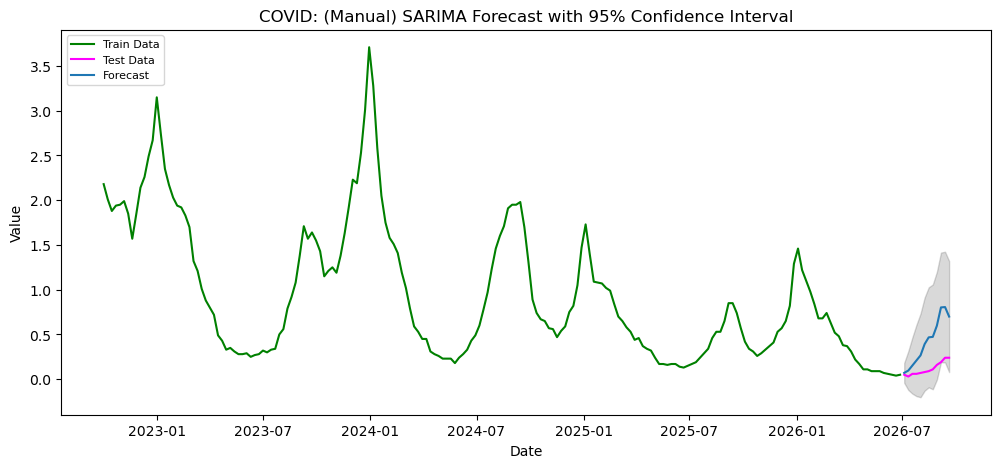

In [68]:
# p,d,q = 2,0,0; P,D,Q, s = 0,1,0, 52 
#STARTING WITH P and Q equals to 0 because the dataset is small and cannot 
# inspect lag 52 after differencing (throwing error)

# Why do we look at P and Q of SARIMAX after seasonally-differencing?? It is because
# SARIMAX is looking at if there is any seasonal relation still left after the 
# seasonal differencing has been done.

manual_sarima_1 = sm.tsa.SARIMAX(train_data_1, order=(2,0,0), 
seasonal_order=(0,1,0,52)) 
manual_sarima_fit_1 = manual_sarima_1.fit()
print(manual_sarima_fit_1.summary())

forecast_steps = 12
forecast_values = manual_sarima_fit_1.forecast(steps=forecast_steps)
srderr = manual_sarima_fit_1.get_prediction(start=len(train_data_1), end=len(train_data_1))

alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series_manualSARIMA_1 = pd.Series(forecast_values, index=test_data_1.index)
lower_series = pd.Series(lower_bound, index=test_data_1.index)
upper_series = pd.Series(upper_bound, index=test_data_1.index)


# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data_1, label='Train Data', color="green")
plt.plot(test_data_1, label='Test Data', color="magenta")
plt.plot(fc_series_manualSARIMA_1, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('COVID: (Manual) SARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:           percent_visits_influenza   No. Observations:                  196
Model:             SARIMAX(2, 0, 0)x(0, 1, 0, 52)   Log Likelihood                 -90.429
Date:                            Mon, 28 Sep 2026   AIC                            186.858
Time:                                    01:00:00   BIC                            195.767
Sample:                                10-01-2022   HQIC                           190.478
                                     - 06-27-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5927      0.031     51.429      0.000       1.532       1.653
ar.L2         -0.7341      0.036   

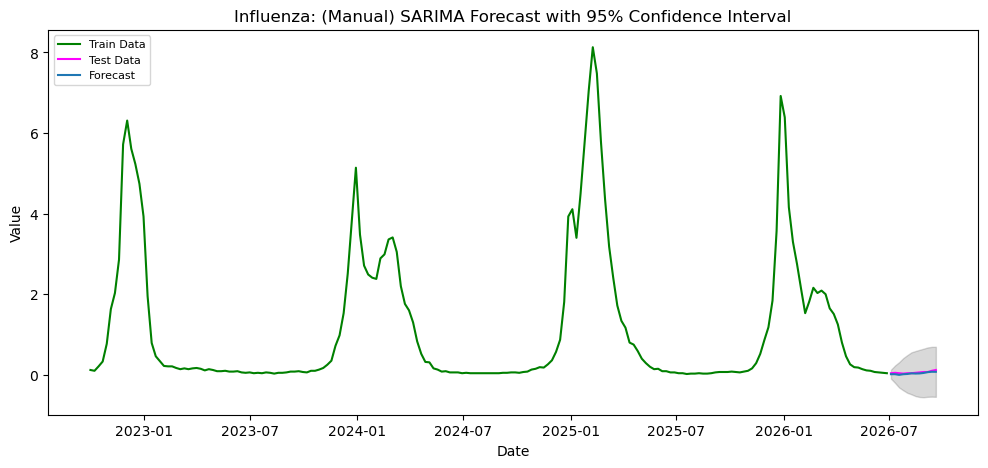

In [69]:
# p,d,q = 2,0,0; P,D,Q, s = 0,1,0, 52 
#STARTING WITH P and Q equals to 0 because the dataset is small and cannot 
# inspect lag 52 after differencing (throwing error)

# Why do we look at P and Q of SARIMAX after seasonally-differencing?? It is because
# SARIMAX is looking at if there is any seasonal relation still left after the 
# seasonal differencing has been done.

manual_sarima_2 = sm.tsa.SARIMAX(train_data_2, order=(2,0,0), 
seasonal_order=(0,1,0,52)) 
manual_sarima_fit_2 = manual_sarima_2.fit()
print(manual_sarima_fit_2.summary())

forecast_steps = 12
forecast_values = manual_sarima_fit_2.forecast(steps=forecast_steps)
srderr = manual_sarima_fit_2.get_prediction(start=len(train_data_2), end=len(train_data_2))

alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series_manualSARIMA_2 = pd.Series(forecast_values, index=test_data_2.index)
lower_series = pd.Series(lower_bound, index=test_data_2.index)
upper_series = pd.Series(upper_bound, index=test_data_2.index)


# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data_2, label='Train Data', color="green")
plt.plot(test_data_2, label='Test Data', color="magenta")
plt.plot(fc_series_manualSARIMA_2, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('Influenza: (Manual) SARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:                 percent_visits_rsv   No. Observations:                  196
Model:             SARIMAX(2, 0, 0)x(0, 1, 0, 52)   Log Likelihood                 178.861
Date:                            Mon, 28 Sep 2026   AIC                           -351.723
Time:                                    01:01:12   BIC                           -342.813
Sample:                                10-01-2022   HQIC                          -348.103
                                     - 06-27-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6291      0.034     48.394      0.000       1.563       1.695
ar.L2         -0.7395      0.035   

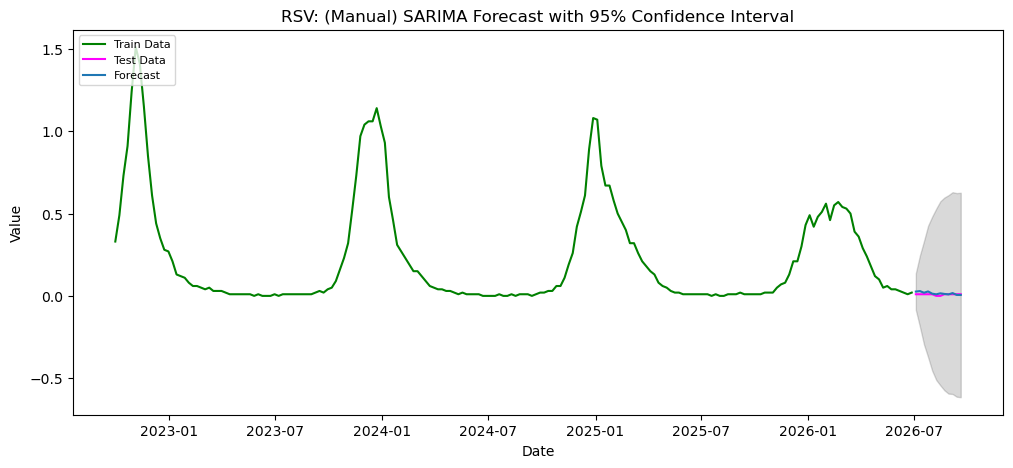

In [70]:
# p,d,q = 2,0,0; P,D,Q, s = 0,1,0, 52 
#STARTING WITH P and Q equals to 0 because the dataset is small and cannot 
# inspect lag 52 after differencing (throwing error)

# Why do we look at P and Q of SARIMAX after seasonally-differencing?? It is because
# SARIMAX is looking at if there is any seasonal relation still left after the 
# seasonal differencing has been done.

manual_sarima_3 = sm.tsa.SARIMAX(train_data_3, order=(2,0,0), 
seasonal_order=(0,1,0,52)) 
manual_sarima_fit_3 = manual_sarima_3.fit()
print(manual_sarima_fit_3.summary())

forecast_steps = 12
forecast_values = manual_sarima_fit_3.forecast(steps=forecast_steps)
srderr = manual_sarima_fit_3.get_prediction(start=len(train_data_3), end=len(train_data_3))

alpha = 0.05
z_score = 1.96  # for a 95% confidence interval
lower_bound = forecast_values - z_score * stderr
upper_bound = forecast_values + z_score * stderr

# Create pandas Series for forecasts and intervals
fc_series_manualSARIMA_3 = pd.Series(forecast_values, index=test_data_3.index)
lower_series = pd.Series(lower_bound, index=test_data_3.index)
upper_series = pd.Series(upper_bound, index=test_data_3.index)


# Plot
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train_data_3, label='Train Data', color="green")
plt.plot(test_data_3, label='Test Data', color="magenta")
plt.plot(fc_series_manualSARIMA_3, label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.15)
plt.title('RSV: (Manual) SARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

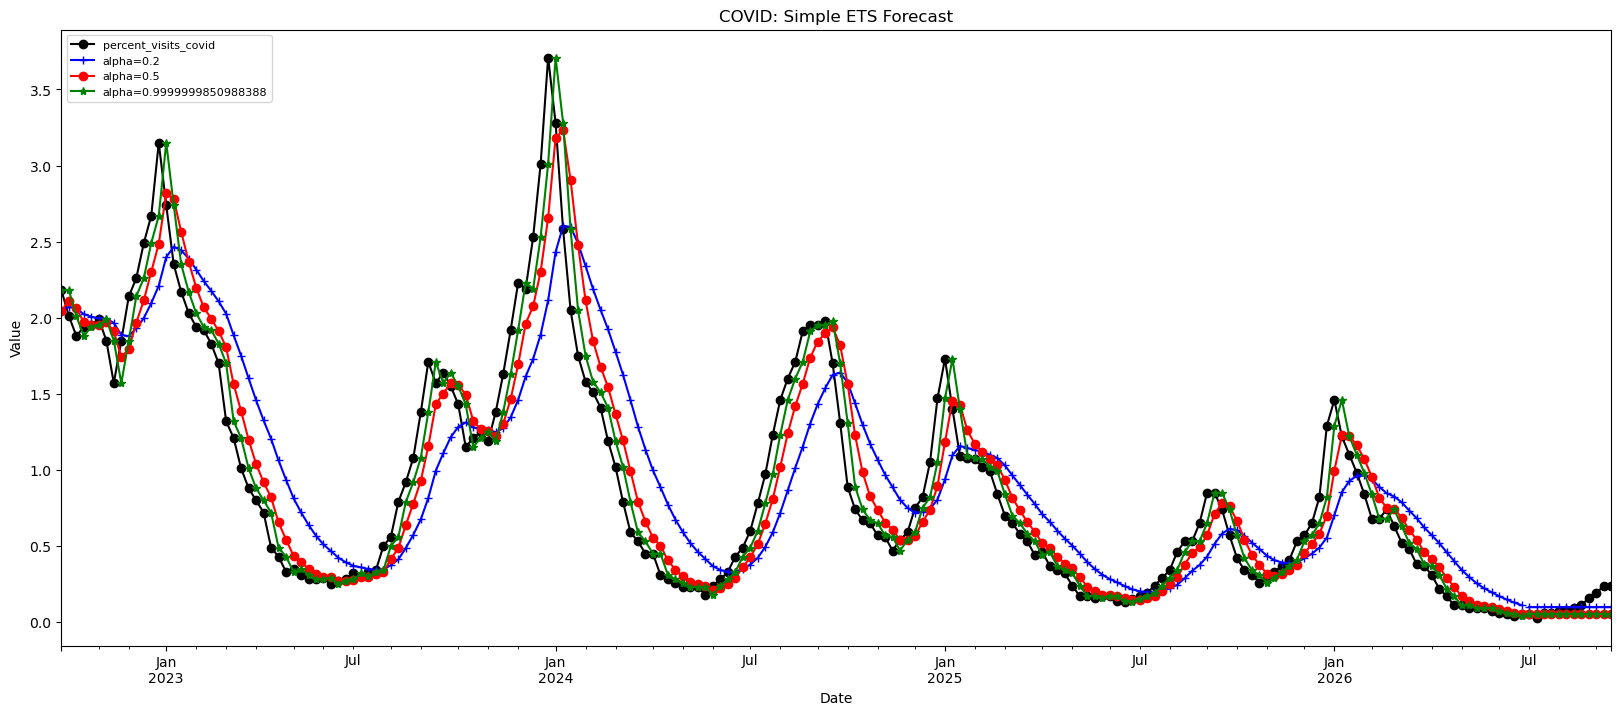

In [72]:
from statsmodels.tsa.api import SimpleExpSmoothing
# Simple Exponential Smoothing Model
## added the initialization_method="estimated" because kept getting an error about it otherwise.
#First Instance
ins1_set1 = SimpleExpSmoothing(train_data_1, initialization_method="estimated").fit(smoothing_level=0.2, optimized=False)
ins_cast1_set1 = ins1_set1.forecast(12).rename('alpha=0.2')

#Second Instance
ins2_set1 = SimpleExpSmoothing(train_data_1, initialization_method="estimated").fit(smoothing_level=0.5, optimized=False)
ins_cast2_set1 = ins2_set1.forecast(12).rename('alpha=0.5')

#Third Instance
ins3_set1 = SimpleExpSmoothing(train_data_1, initialization_method="estimated").fit()
ins_cast3_set1 = ins3_set1.forecast(12).rename('alpha=%s'%ins3_set1.model.params['smoothing_level'])

#After creating model we will visualize the plot
ax = covid_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for alpha =0.2
ins_cast1_set1.plot(marker='+', ax=ax, color='blue', legend=True)
ins1_set1.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for alpha = 0.5
ins_cast2_set1.plot(marker='o', ax=ax, color='red', legend=True)
ins2_set1.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for alpha=Optimized by statsmodel
ins_cast3_set1.plot(marker='*', ax=ax, color='green', legend=True)
ins3_set1.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('COVID: Simple ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)

plt.show()

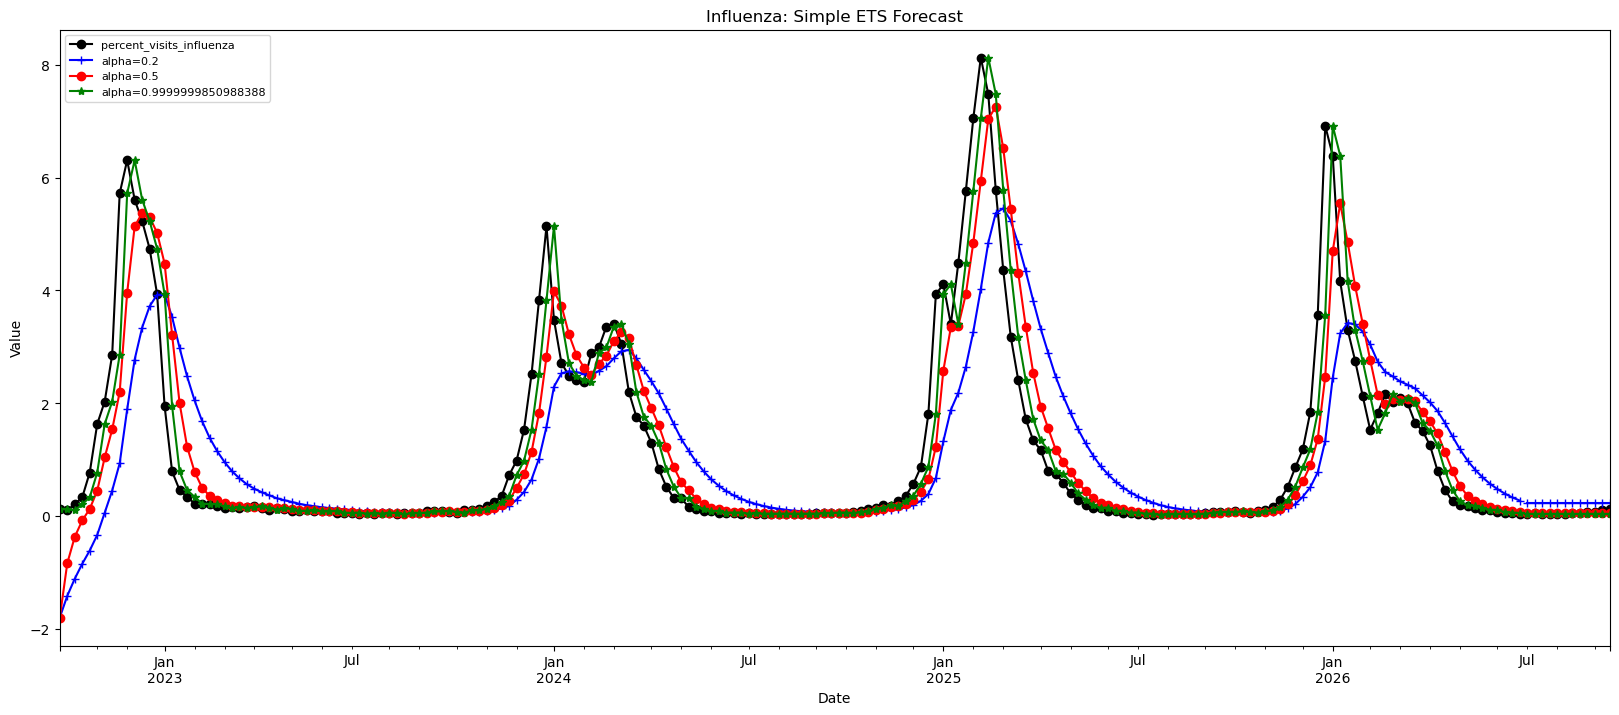

In [74]:
from statsmodels.tsa.api import SimpleExpSmoothing
# Simple Exponential Smoothing Model
## added the initialization_method="estimated" because kept getting an error about it otherwise.
#First Instance
ins1_set2 = SimpleExpSmoothing(train_data_2, initialization_method="estimated").fit(smoothing_level=0.2, optimized=False)
ins_cast1_set2 = ins1_set2.forecast(12).rename('alpha=0.2')

#Second Instance
ins2_set2 = SimpleExpSmoothing(train_data_2, initialization_method="estimated").fit(smoothing_level=0.5, optimized=False)
ins_cast2_set2 = ins2_set2.forecast(12).rename('alpha=0.5')

#Third Instance
ins3_set2 = SimpleExpSmoothing(train_data_2, initialization_method="estimated").fit()
ins_cast3_set2 = ins3_set2.forecast(12).rename('alpha=%s'%ins3_set2.model.params['smoothing_level'])

#After creating model we will visualize the plot
ax = influenza_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for alpha =0.2
ins_cast1_set2.plot(marker='+', ax=ax, color='blue', legend=True)
ins1_set2.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for alpha = 0.5
ins_cast2_set2.plot(marker='o', ax=ax, color='red', legend=True)
ins2_set2.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for alpha=Optimized by statsmodel
ins_cast3_set2.plot(marker='*', ax=ax, color='green', legend=True)
ins3_set2.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Influenza: Simple ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)

plt.show()

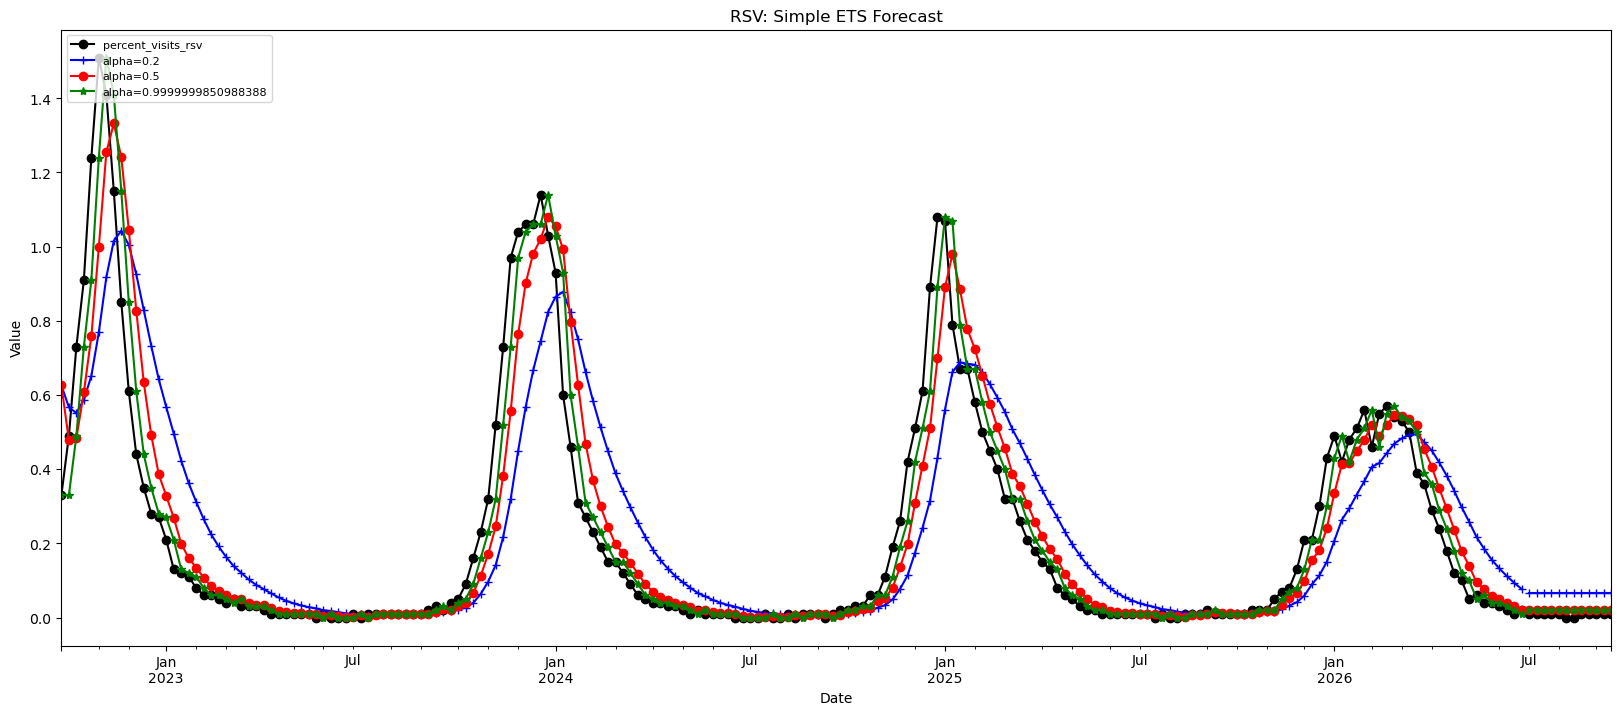

In [77]:
from statsmodels.tsa.api import SimpleExpSmoothing
# Simple Exponential Smoothing Model
## added the initialization_method="estimated" because kept getting an error about it otherwise.
#First Instance
ins1_set3 = SimpleExpSmoothing(train_data_3, initialization_method="estimated").fit(smoothing_level=0.2, optimized=False)
ins_cast1_set3 = ins1_set3.forecast(12).rename('alpha=0.2')

#Second Instance
ins2_set3 = SimpleExpSmoothing(train_data_3, initialization_method="estimated").fit(smoothing_level=0.5, optimized=False)
ins_cast2_set3 = ins2_set3.forecast(12).rename('alpha=0.5')

#Third Instance
ins3_set3 = SimpleExpSmoothing(train_data_3, initialization_method="estimated").fit()
ins_cast3_set3 = ins3_set3.forecast(12).rename('alpha=%s'%ins3_set3.model.params['smoothing_level'])

#After creating model we will visualize the plot
ax = rsv_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for alpha =0.2
ins_cast1_set3.plot(marker='+', ax=ax, color='blue', legend=True)
ins1_set3.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for alpha = 0.5
ins_cast2_set3.plot(marker='o', ax=ax, color='red', legend=True)
ins2_set3.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for alpha=Optimized by statsmodel
ins_cast3_set3.plot(marker='*', ax=ax, color='green', legend=True)
ins3_set3.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('RSV: Simple ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)

plt.show()

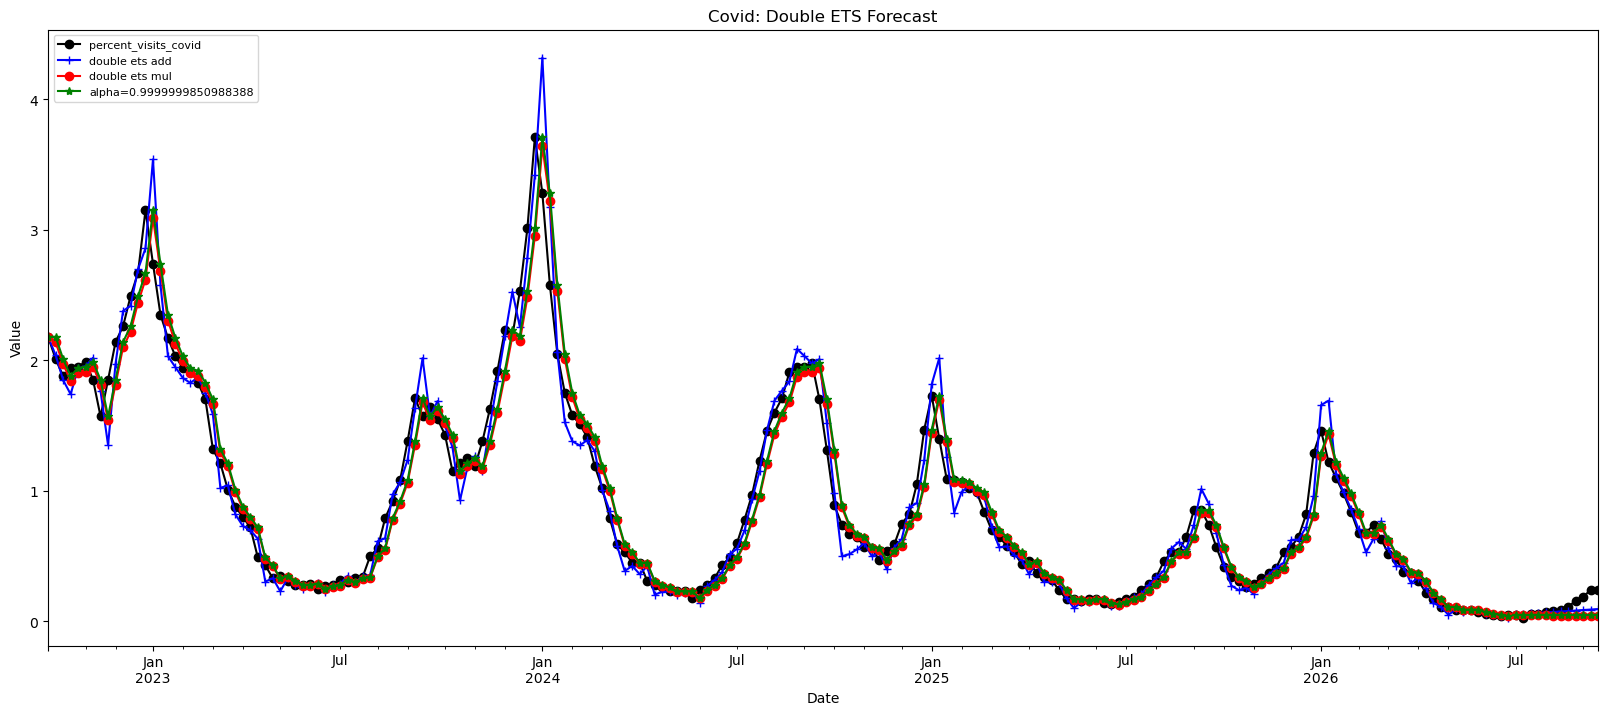

In [78]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
## double ETS
double_ets_add_set1 = ExponentialSmoothing(train_data_1, trend = 'add').fit()
double_ets_mul_set1 = ExponentialSmoothing(train_data_1, trend = 'mul').fit()

double_ets_add_pred_set1 = double_ets_add_set1.forecast(12)
double_ets_mul_pred_set1 = double_ets_mul_set1.forecast(12)
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = covid_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
double_ets_add_pred_set1.plot(marker='+', ax=ax, color='blue', legend=True, label = 'double ets add')
double_ets_add_set1.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for double ETS multiplicative
double_ets_mul_pred_set1.plot(marker='o', ax=ax, color='red', legend=True, label = 'double ets mul')
double_ets_mul_set1.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for simple exponential smooting alpha=Optimized by statsmodel
ins_cast3_set1.plot(marker='*', ax=ax, color='green', legend=True)
ins3_set1.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Covid: Double ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()



c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)


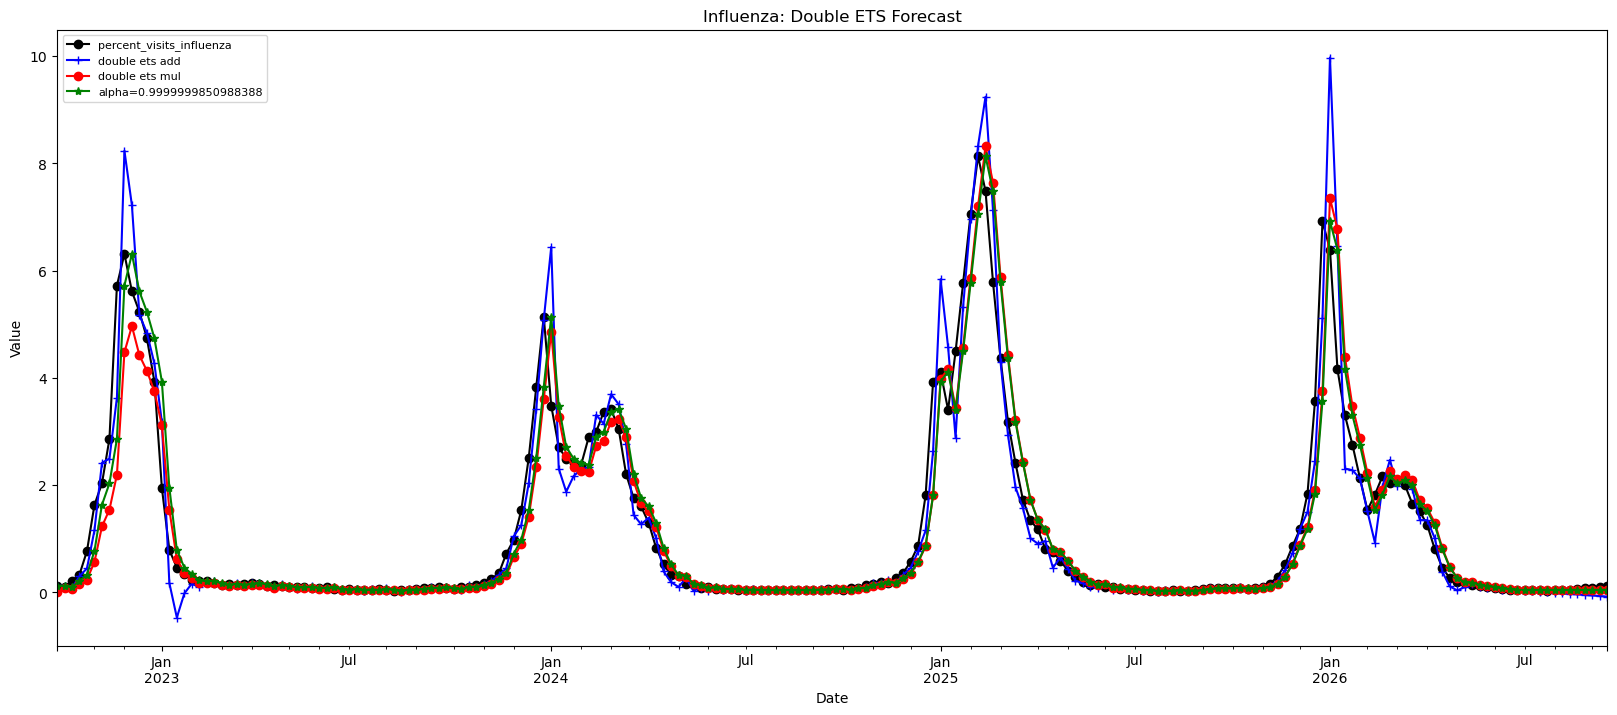

In [80]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
## double ETS
double_ets_add_set2 = ExponentialSmoothing(train_data_2, trend = 'add').fit()
double_ets_mul_set2 = ExponentialSmoothing(train_data_2, trend = 'mul').fit()

double_ets_add_pred_set2 = double_ets_add_set2.forecast(12)
double_ets_mul_pred_set2 = double_ets_mul_set2.forecast(12)
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = influenza_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
double_ets_add_pred_set2.plot(marker='+', ax=ax, color='blue', legend=True, label = 'double ets add')
double_ets_add_set2.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for double ETS multiplicative
double_ets_mul_pred_set2.plot(marker='o', ax=ax, color='red', legend=True, label = 'double ets mul')
double_ets_mul_set2.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for simple exponential smooting alpha=Optimized by statsmodel
ins_cast3_set2.plot(marker='*', ax=ax, color='green', legend=True)
ins3_set2.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Influenza: Double ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()



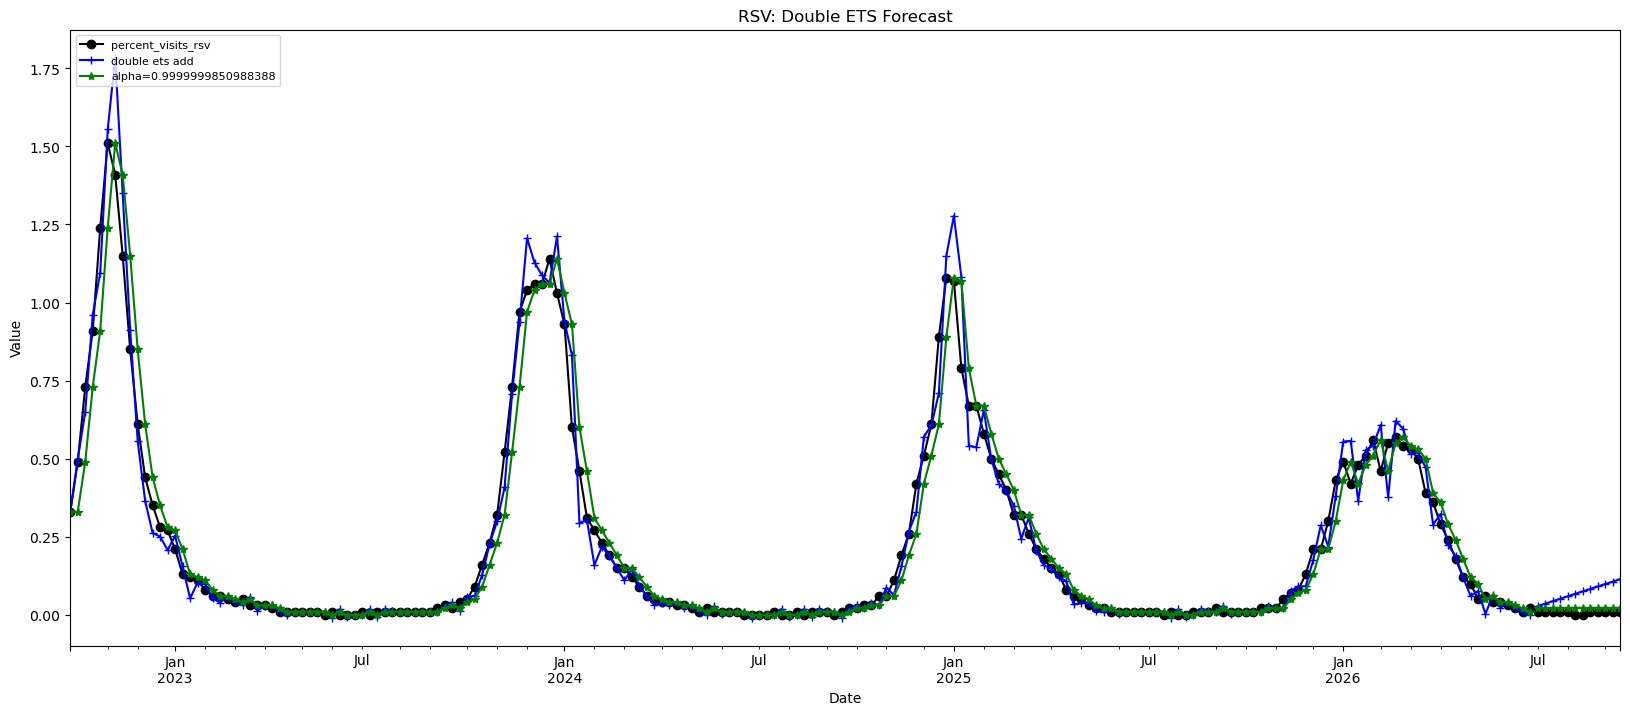

In [85]:
## SKIPPING MULTIPLICATIVE FOR RSV DUE TO PRESENCE OF 0 VALUE
## double ETS
double_ets_add_set2 = ExponentialSmoothing(train_data_3, trend = 'add').fit()

double_ets_add_pred_set3 = double_ets_add_set3.forecast(12)
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = rsv_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
double_ets_add_pred_set3.plot(marker='+', ax=ax, color='blue', legend=True, label = 'double ets add')
double_ets_add_set3.fittedvalues.plot(marker='+', ax=ax, color='blue')


#Plot for simple exponential smooting alpha=Optimized by statsmodel
ins_cast3_set3.plot(marker='*', ax=ax, color='green', legend=True)
ins3_set3.fittedvalues.plot(marker='*', ax=ax, color='green')

plt.title('RSV: Double ETS Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()


In [84]:
print(train_data_3.min())
print((train_data_3 <= 0).sum())

percent_visits_rsv    0.0
dtype: float64
percent_visits_rsv    16
dtype: int64


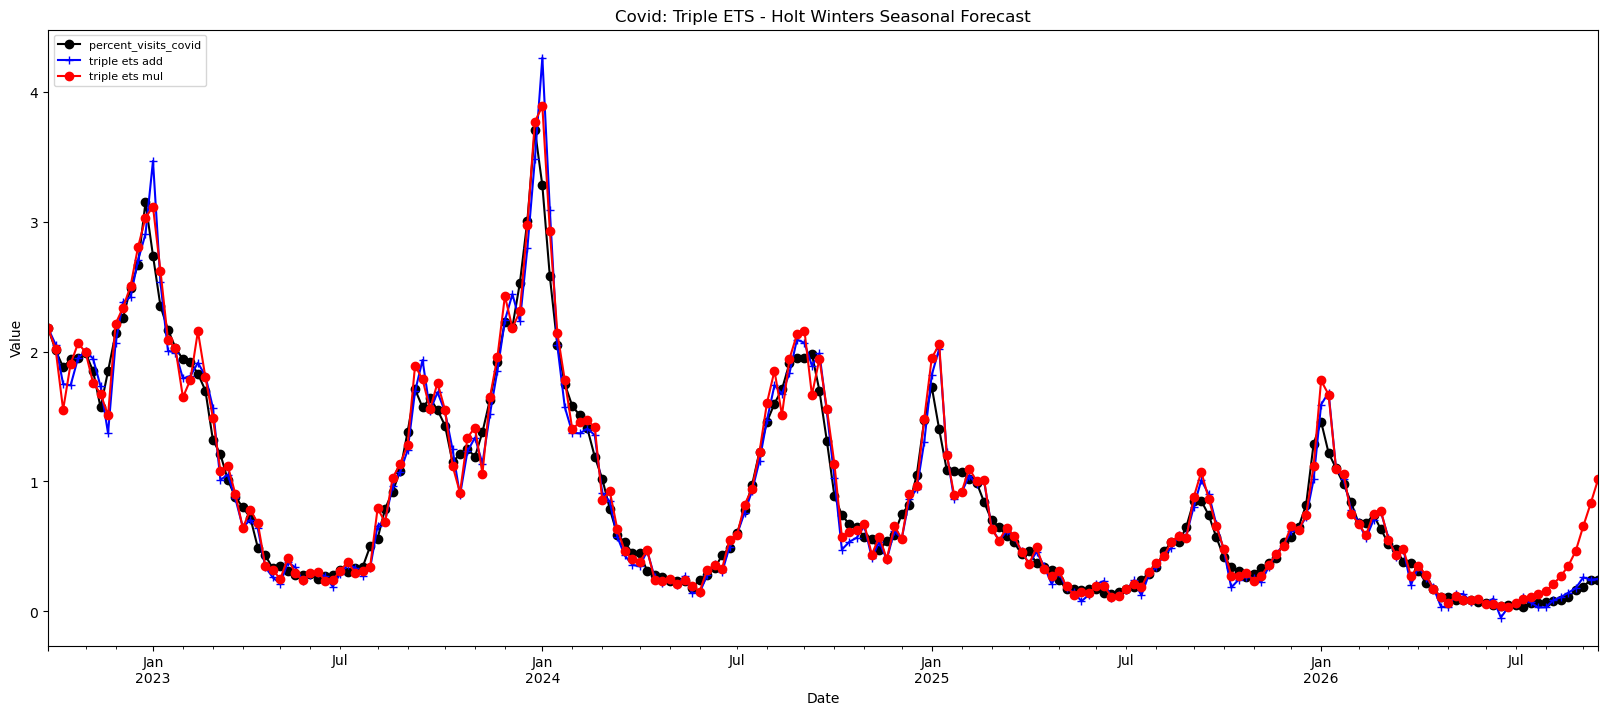

In [86]:
### triple ETS
# triple ETS - Holt Winter's Seasonal Method
triple_ets_add_set1 = ExponentialSmoothing(train_data_1, trend = 'add', seasonal = 'add', seasonal_periods=12).fit()
triple_ets_mul_set1 = ExponentialSmoothing(train_data_1, trend = 'mul', seasonal = 'mul', seasonal_periods=12).fit()

triple_ets_add_pred_set1 = triple_ets_add_set1.forecast(12)
triple_ets_mul_pred_set1 = triple_ets_mul_set1.forecast(12)
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = covid_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
triple_ets_add_pred_set1.plot(marker='+', ax=ax, color='blue', legend=True, label = 'triple ets add')
triple_ets_add_set1.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for double ETS multiplicative
triple_ets_mul_pred_set1.plot(marker='o', ax=ax, color='red', legend=True, label = 'triple ets mul')
triple_ets_mul_set1.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for simple exponential smooting alpha=Optimized by statsmodel
#ins_cast3.plot(marker='*', ax=ax, color='green', legend=True)
#ins3.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Covid: Triple ETS - Holt Winters Seasonal Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

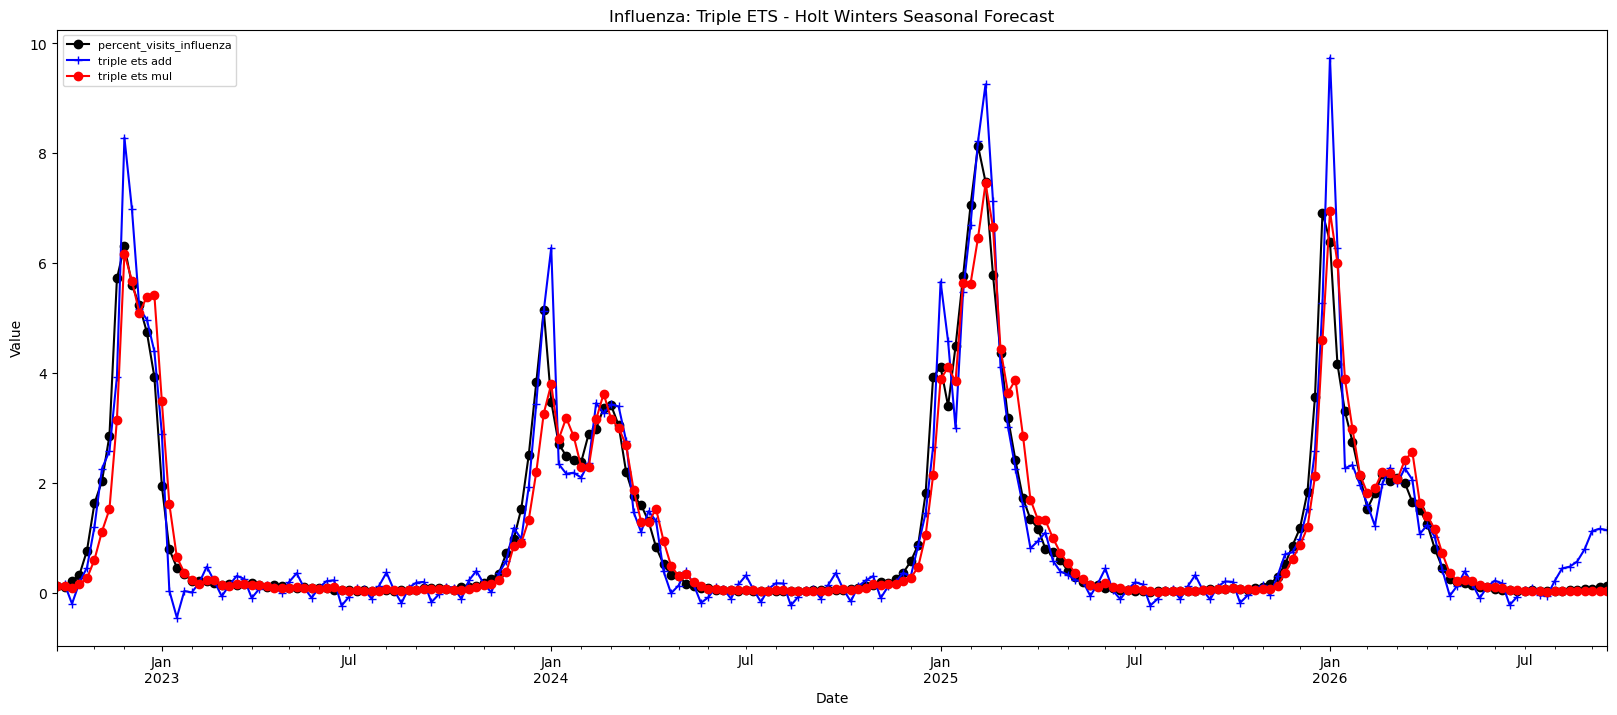

In [87]:
### triple ETS
# triple ETS - Holt Winter's Seasonal Method
triple_ets_add_set2 = ExponentialSmoothing(train_data_2, trend = 'add', seasonal = 'add', seasonal_periods=12).fit()
triple_ets_mul_set2 = ExponentialSmoothing(train_data_2, trend = 'mul', seasonal = 'mul', seasonal_periods=12).fit()

triple_ets_add_pred_set2 = triple_ets_add_set2.forecast(12)
triple_ets_mul_pred_set2 = triple_ets_mul_set2.forecast(12)
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = influenza_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
triple_ets_add_pred_set2.plot(marker='+', ax=ax, color='blue', legend=True, label = 'triple ets add')
triple_ets_add_set2.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for double ETS multiplicative
triple_ets_mul_pred_set2.plot(marker='o', ax=ax, color='red', legend=True, label = 'triple ets mul')
triple_ets_mul_set2.fittedvalues.plot(marker='o', ax=ax, color='red')

#Plot for simple exponential smooting alpha=Optimized by statsmodel
#ins_cast3.plot(marker='*', ax=ax, color='green', legend=True)
#ins3.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('Influenza: Triple ETS - Holt Winters Seasonal Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

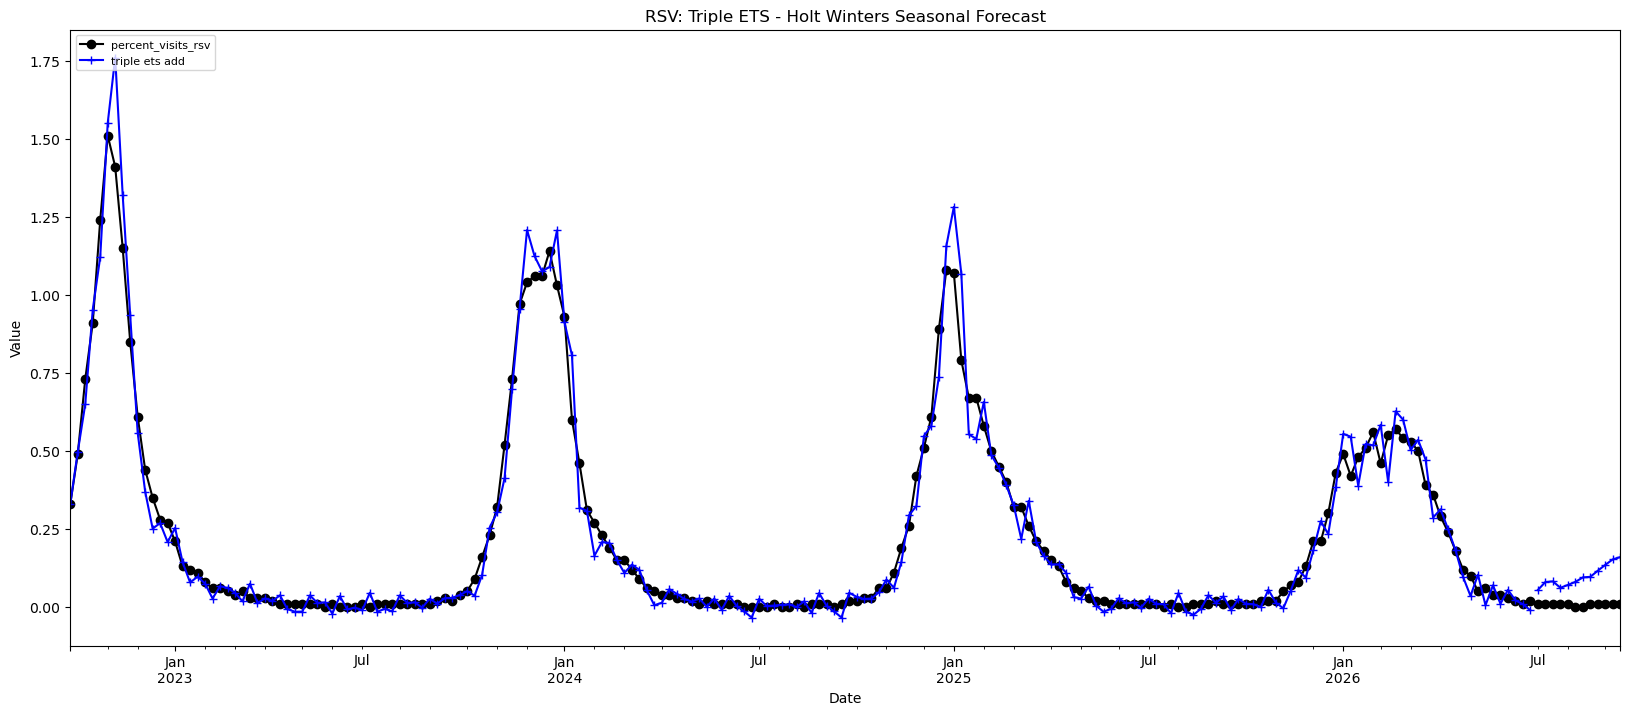

In [88]:
# SKIPPING MULTIPLICATIVE FOR RSV AGAIN

### triple ETS
# triple ETS - Holt Winter's Seasonal Method
triple_ets_add_set3 = ExponentialSmoothing(train_data_3, trend = 'add', seasonal = 'add', seasonal_periods=12).fit()

triple_ets_add_pred_set3 = triple_ets_add_set3.forecast(12)
#plot the train, test, and predictions

#After creating model we will visualize the plot
ax = rsv_df.plot(marker='o', color='black', figsize=(20,8), legend=True)

#Plot for double ETS additive
triple_ets_add_pred_set3.plot(marker='+', ax=ax, color='blue', legend=True, label = 'triple ets add')
triple_ets_add_set3.fittedvalues.plot(marker='+', ax=ax, color='blue')

#Plot for simple exponential smooting alpha=Optimized by statsmodel
#ins_cast3.plot(marker='*', ax=ax, color='green', legend=True)
#ins3.fittedvalues.plot(marker='*', ax=ax, color='green')
plt.title('RSV: Triple ETS - Holt Winters Seasonal Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', fontsize=8)
plt.show()

##### Step 7: Evaluating Models

In [89]:
#define metrics dataframe which will be used below for storing results
metrics_dataframe = pd.DataFrame(columns=['Model', 'RMSE', 'MAE', 'MAPE',
                                          "MASE", "WAPE"])
def metrics_cal(actuals, predictions, model, data):
    mse = mean_squared_error(actuals, predictions)
    rmse = sqrt(mse)
    mae = mean_absolute_error(actuals, predictions)
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

    # additional evaluation metrics
    mase = mae / np.mean(np.abs(np.diff(data.values.flatten())))
    wape = np.sum(np.abs(actuals - predictions)) / np.sum(np.abs(actuals)) * 100

    df = pd.DataFrame({'Model': [model],
                       'RMSE': [rmse],
                       'MAE': [mae],
                       'MAPE': [mape],
                       'MASE': [mase],
                       'WAPE': [wape]})

    global metrics_dataframe
    metrics_dataframe = pd.concat([metrics_dataframe, df], ignore_index=True)
    return metrics_dataframe

In [115]:
set_dataframes = []

training_datasets = [train_data_1, train_data_2, train_data_3]
testing_datasets = [test_data_1, test_data_2, test_data_3]

# Simple ETS
ins_cast1_sets = [ins_cast1_set1, ins_cast1_set2, ins_cast1_set3]
ins_cast2_sets = [ins_cast2_set1, ins_cast2_set2, ins_cast2_set3]
ins_cast3_sets = [ins_cast3_set1, ins_cast3_set2, ins_cast3_set3]

# Double ETS
double_ets_add_pred_sets = [double_ets_add_pred_set1, double_ets_add_pred_set2, double_ets_add_pred_set3]
double_ets_mul_pred_sets = [double_ets_mul_pred_set1, double_ets_mul_pred_set2]

# Triple ETS
triple_ets_add_pred_sets = [triple_ets_add_pred_set1, triple_ets_add_pred_set2, triple_ets_add_pred_set3]
triple_ets_mul_pred_sets = [triple_ets_mul_pred_set1, triple_ets_mul_pred_set2]

# Manual ARIMA
manual_arima_sets = [fc_series_set1, fc_series_set2, fc_series_set3]

# Manual SARIMA
manual_sarima_sets = [fc_series_manualSARIMA_1, fc_series_manualSARIMA_2, fc_series_manualSARIMA_3]

# Auto ARIMA
auto_arima_sets = [fc_series_auto_nonseasonal_1, fc_series_auto_nonseasonal_2, fc_series_auto_nonseasonal_3]

set_dataframes = []

for i in range(3):

    train = training_datasets[i]
    test = testing_datasets[i]

    metrics_dataframe = pd.DataFrame(
        columns=["Model", "RMSE", "MAE", "MAPE", "MASE", "WAPE"]
    )

    metrics_cal(
        test.values.flatten(),
        ins_cast1_sets[i].values.flatten(),
        "Simple 0.2", train
    )

    metrics_cal(
        test.values.flatten(),
        ins_cast2_sets[i].values.flatten(),
        "Simple 0.5", train
    )

    metrics_cal(
        test.values.flatten(),
        ins_cast3_sets[i].values.flatten(),
        "Simple 1", train
    )

    metrics_cal(
        test.values.flatten(),
        double_ets_add_pred_sets[i].values.flatten(),
        "Double Add", train
    )

    # only COVID and influenza
    if i < 2:
        metrics_cal(
            test.values.flatten(),
            double_ets_mul_pred_sets[i].values.flatten(),
            "Double Mul", train
        )

    metrics_cal(
        test.values.flatten(),
        triple_ets_add_pred_sets[i].values.flatten(),
        "Triple Add", train
    )

    # only COVID and influenza
    if i < 2:
        metrics_cal(
            test.values.flatten(),
            triple_ets_mul_pred_sets[i].values.flatten(),
            "Triple Mul", train
        )

    metrics_cal(
        test.values.flatten(),
        manual_arima_sets[i].values.flatten(),
        "Manual ARIMA", train
    )

    metrics_cal(
        test.values.flatten(),
        manual_sarima_sets[i].values.flatten(),
        "Manual SARIMA", train
    )

    metrics_cal(
        test.values.flatten(),
        auto_arima_sets[i].values.flatten(),
        "Auto ARIMA", train
    )

    set_dataframes.append(metrics_dataframe.copy())

C:\Users\tanis\AppData\Local\Temp\ipykernel_13708\1191322838.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_dataframe = pd.concat([metrics_dataframe, df], ignore_index=True)
C:\Users\tanis\AppData\Local\Temp\ipykernel_13708\1191322838.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_dataframe = pd.concat([metrics_dataframe, df], ignore_index=True)
C:\Users\tanis\AppData\Local\Temp\ipykernel_13708\1191322838.py:8: RuntimeWarning: divide by zero encountered in divide
  ma

In [116]:
test_pred_dataframes = []

for i in range(3):  # 0 = COVID, 1 = Influenza, 2 = RSV
    
    test_pred_df = testing_datasets[i].copy()

    # Models available for all 3 diseases
    test_pred_df = test_pred_df.assign(
        Simple_02=ins_cast1_sets[i].values.flatten(),
        Simple_05=ins_cast2_sets[i].values.flatten(),
        Simple_1=ins_cast3_sets[i].values.flatten(),
        Double_Add=double_ets_add_pred_sets[i].values.flatten(),
        Triple_Add=triple_ets_add_pred_sets[i].values.flatten(),
        Manual_ARIMA=manual_arima_sets[i].values.flatten(),
        Manual_SARIMA=manual_sarima_sets[i].values.flatten(),
        Auto_ARIMA=auto_arima_sets[i].values.flatten()
    )

    prediction_columns = [
        "Simple_02",
        "Simple_05",
        "Simple_1",
        "Double_Add",
        "Triple_Add",
        "Manual_ARIMA",
        "Manual_SARIMA",
        "Auto_ARIMA"
    ]

    # Multiplicative ETS works for COVID and Influenza,
    # but not RSV because RSV contains zero values
    if i != 2:
        test_pred_df["Double_Mul"] = (
            double_ets_mul_pred_sets[i].values.flatten()
        )

        test_pred_df["Triple_Mul"] = (
            triple_ets_mul_pred_sets[i].values.flatten()
        )

        prediction_columns.extend([
            "Double_Mul",
            "Triple_Mul"
        ])

    # Average prediction across all models available for that disease
    test_pred_df["Average_Prediction"] = (
        test_pred_df[prediction_columns].mean(axis=1)
    )

    test_pred_dataframes.append(test_pred_df)

### COVID Average Predictions

In [117]:
set1_avg_predictions = test_pred_dataframes[0]
set1_avg_predictions.head()

,percent_visits_covid,Simple_02,Simple_05,Simple_1,Double_Add,Triple_Add,Manual_ARIMA,Manual_SARIMA,Auto_ARIMA,Double_Mul,Triple_Mul,Average_Prediction
week_end,,,,,,,,,,,,
2026-07-04,0.05,0.098825,0.050196,0.05,0.053728,0.056318,0.093852,0.071060,0.088904,0.049043,0.064973,0.067690
2026-07-11,0.03,0.098825,0.050196,0.05,0.057456,0.105935,0.155233,0.096300,0.142399,0.048104,0.092034,0.089648
2026-07-18,0.06,0.098825,0.050196,0.05,0.061184,0.068212,0.224088,0.152884,0.196892,0.047183,0.111542,0.106100
2026-07-25,0.06,0.098825,0.050196,0.05,0.064912,0.028781,0.294365,0.209661,0.247829,0.046279,0.129277,0.122012
2026-08-01,0.07,0.098825,0.050196,0.05,0.068640,0.030135,0.362543,0.266180,0.295441,0.045393,0.154348,0.142170


### COVID Model Evaluations

In [118]:
set1_df = set_dataframes[0]
set1_df

,Model,RMSE,MAE,MAPE,MASE,WAPE
0,Simple 0.2,0.072709,0.058137,62.085289,0.469433,50.554327
1,Simple 0.5,0.096045,0.068203,47.075919,0.550705,59.306679
2,Simple 1,0.096177,0.068333,47.152406,0.551760,59.420290
3,Double Add,0.071679,0.046982,32.329427,0.379356,40.853732
4,Double Mul,0.102157,0.073823,51.434103,0.596087,64.193993
5,Triple Add,0.035466,0.026108,41.159878,0.210811,22.702671
6,Triple Mul,0.339340,0.246769,178.165594,1.992546,214.581900
7,Manual ARIMA,0.345048,0.316675,310.451593,2.557006,275.369904
8,Manual SARIMA,0.358859,0.304647,259.292041,2.459880,264.910206
9,Auto ARIMA,0.245587,0.229638,236.533751,1.854223,199.685588


### COVID Models Ranked

In [119]:
metrics = ["RMSE", "MAE", "MAPE", "MASE", "WAPE"]
model_dict = {}
for metric in metrics:
    sorted_models = set1_df.sort_values(by=metric)["Model"]
    score = 0
    for model in sorted_models:
        if model in model_dict.keys(): 
            model_dict[model] += score
        else:
            model_dict[model] = score
        score += 1
model_dict    

{'Triple Add': 1,
 'Double Add': 4,
 'Simple 0.2': 13,
 'Simple 0.5': 14,
 'Simple 1': 19,
 'Double Mul': 24,
 'Auto ARIMA': 31,
 'Triple Mul': 34,
 'Manual ARIMA': 44,
 'Manual SARIMA': 41}

### Influenza Average Predictions

In [120]:
set2_avg_predictions = test_pred_dataframes[1]
set2_avg_predictions.head()

,percent_visits_influenza,Simple_02,Simple_05,Simple_1,Double_Add,Triple_Add,Manual_ARIMA,Manual_SARIMA,Auto_ARIMA,Double_Mul,Triple_Mul,Average_Prediction
week_end,,,,,,,,,,,,
2026-07-04,0.04,0.225998,0.052418,0.04,0.029923,0.044050,0.135007,0.015488,0.086072,0.039852,0.036353,0.070516
2026-07-11,0.05,0.225998,0.052418,0.04,0.019846,0.084140,0.281148,0.015642,0.171310,0.039704,0.032056,0.096226
2026-07-18,0.04,0.225998,0.052418,0.04,0.009769,-0.044122,0.442920,-0.000799,0.268810,0.039556,0.024422,0.105897
2026-07-25,0.03,0.225998,0.052418,0.04,-0.000308,-0.055771,0.598598,0.014756,0.375611,0.039409,0.020252,0.131096
2026-08-01,0.04,0.225998,0.052418,0.04,-0.010385,0.212922,0.736347,0.020990,0.488806,0.039263,0.024549,0.183091


### Influenza Model Evaluations

In [121]:
set2_df = set_dataframes[1]
set2_df

,Model,RMSE,MAE,MAPE,MASE,WAPE
0,Simple 0.2,0.168840,0.166831,346.166077,0.560318,281.967929
1,Simple 0.5,0.026830,0.019570,31.278948,0.065726,33.075427
2,Simple 1,0.032275,0.020833,26.587302,0.069971,35.211268
3,Double Add,0.102824,0.084667,130.459164,0.284363,143.099431
4,Double Mul,0.033184,0.021687,27.852917,0.072838,36.653960
5,Triple Add,0.609426,0.465013,680.544744,1.561791,785.938018
6,Triple Mul,0.036161,0.028318,42.210424,0.095108,47.860849
7,Manual ARIMA,0.789622,0.724423,1290.035661,2.433042,1224.376381
8,Manual SARIMA,0.026140,0.023030,43.044676,0.077347,38.923221
9,Auto ARIMA,0.702631,0.605719,994.759038,2.034363,1023.749876


### Influenza Models Ranked

In [125]:
metrics = ["RMSE", "MAE", "MAPE", "MASE", "WAPE"]
model_dict = {}
for metric in metrics:
    sorted_models = set2_df.sort_values(by=metric)["Model"]
    score = 0
    for model in sorted_models:
        if model in model_dict.keys(): 
            model_dict[model] += score
        else:
            model_dict[model] = score
        score += 1
model_dict    

{'Manual SARIMA': 13,
 'Simple 0.5': 3,
 'Simple 1': 5,
 'Double Mul': 10,
 'Triple Mul': 19,
 'Double Add': 25,
 'Simple 0.2': 30,
 'Triple Add': 35,
 'Auto ARIMA': 40,
 'Manual ARIMA': 45}

### RSV Average Predictions

In [122]:
set3_avg_predictions = test_pred_dataframes[2]
set3_avg_predictions.head()

,percent_visits_rsv,Simple_02,Simple_05,Simple_1,Double_Add,Triple_Add,Manual_ARIMA,Manual_SARIMA,Auto_ARIMA,Average_Prediction
week_end,,,,,,,,,,
2026-07-04,0.01,0.06569,0.019958,0.02,0.027837,0.054706,0.038739,0.026291,0.038555,0.036472
2026-07-11,0.01,0.06569,0.019958,0.02,0.035674,0.080193,0.062701,0.029144,0.062229,0.046949
2026-07-18,0.01,0.06569,0.019958,0.02,0.043510,0.082077,0.089042,0.019139,0.088243,0.053457
2026-07-25,0.01,0.06569,0.019958,0.02,0.051347,0.061604,0.115562,0.027022,0.114452,0.059454
2026-08-01,0.01,0.06569,0.019958,0.02,0.059184,0.070644,0.140663,0.013575,0.139292,0.066126


### RSV Model Evaluations

In [123]:
set3_df = set_dataframes[2]
set3_df

,Model,RMSE,MAE,MAPE,MASE,WAPE
0,Simple 0.2,0.057478,0.057357,inf,1.266658,688.282731
1,Simple 0.5,0.012208,0.011625,inf,0.256720,139.497602
2,Simple 1,0.012247,0.011667,inf,0.257644,139.999998
3,Double Add,0.068303,0.062606,inf,1.382577,751.271102
4,Triple Add,0.096256,0.090419,inf,1.996793,1085.026785
5,Manual ARIMA,0.162149,0.148634,inf,3.282400,1783.605588
6,Manual SARIMA,0.010954,0.009063,inf,0.200148,108.757571
7,Auto ARIMA,0.160879,0.147423,inf,3.255668,1769.079773


### RSV Models Ranked

In [126]:
metrics = ["RMSE", "MAE", "MAPE", "MASE", "WAPE"]
model_dict = {}
for metric in metrics:
    sorted_models = set3_df.sort_values(by=metric)["Model"]
    score = 0
    for model in sorted_models:
        if model in model_dict.keys(): 
            model_dict[model] += score
        else:
            model_dict[model] = score
        score += 1
model_dict    

{'Manual SARIMA': 6,
 'Simple 0.5': 5,
 'Simple 1': 10,
 'Simple 0.2': 12,
 'Double Add': 19,
 'Triple Add': 24,
 'Auto ARIMA': 31,
 'Manual ARIMA': 33}